# AFL Data Foundations — EDA, Feature Engineering & Prediction Targets


### Purpose
This notebook prepares the AFL dataset for the rest of the week's modelling and assistant-building work.

It does four things:

1. **Understand the data**: inventory the files, validate their grain and joins, and document data-quality issues.
2. **Define prediction targets**: specify exactly what a match winner and "top player" mean.
3. **Explore the data**: investigate team, player, venue, travel, form and performance patterns.
4. **Build leakage-safe features**: create only information that would have been available **before** the match being predicted.

> **Core modelling rule:** every predictive feature must be computed using information available before the target match. Current-match outcomes or statistics must never be used as inputs.

### Reproducibility
- Fixed random seeds are used where randomness is required.
- Match-level modelling uses a **strict time-based holdout**.
- Player-level modelling uses the same time principle.
- Feature tables and definitions are produced in a form that can be reused on Day 2.


# AFL Data Foundations — EDA, Feature Engineering & Prediction Targets

**Goal:** Understand the raw AFL data end-to-end, define prediction targets precisely, run EDA,
engineer leakage-safe features, and produce a reproducible time-based train/hold-out split —
the shared contract for the rest of the week's modelling and the domain-locked chat agent.

**Data files :**
1. `player_rounds_raw.csv`: player-level, per-match round-by-round stats (1983–2025)
2. `team_matches_raw.csv`: team-level, per-match home/away rows (1983–2025)
3. `merged_players.csv`: player-level, per-**season** aggregates (regular season vs finals split)


## 9. Time-Based Train / Hold-Out Split

A random split is inappropriate for this task because sports data are chronological.

A random split can train on future matches and evaluate on earlier matches, making performance look better than what would be achievable in real deployment.

The reusable split function therefore trains on earlier seasons and holds out the most recent season.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA = Path('data')
FIGS = Path('figs')
OUT = Path('output')
FIGS.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)

PLAYER_FILE = DATA / 'afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv'
TEAM_FILE = DATA / 'team_matches_home_away_raw - team_matches_home_away_raw.csv.csv'
MERGED_PLAYERS_FILE = DATA / 'merged_players.csv'

required_files = [PLAYER_FILE, TEAM_FILE, MERGED_PLAYERS_FILE]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing input file(s). Put the supplied AFL CSV files in ./data before running the notebook:\n"
        + "\n".join(f" - {p}" for p in missing)
    )

player_rounds_raw = pd.read_csv(PLAYER_FILE, low_memory=False)
team_matches_raw = pd.read_csv(TEAM_FILE, low_memory=False)
merged_players = pd.read_csv(MERGED_PLAYERS_FILE, low_memory=False)

print('player_rounds_raw :', player_rounds_raw.shape)
print('team_matches_raw  :', team_matches_raw.shape)
print('merged_players    :', merged_players.shape)

# Canonical team normalisation is defined ONCE and reused everywhere.
def norm_team(series):
    normalized = (
        series.astype('string')
        .str.strip()
        .str.lower()
        .str.replace(r'\s+', ' ', regex=True)
    )
    aliases = {
        'w. bulldogs': 'western bulldogs',
    }
    return normalized.replace(aliases)

# Work on canonical cleaned tables from this point onward.
player_rounds = player_rounds_raw.copy()
team_matches = team_matches_raw.copy()

# Normalize numeric/stat columns once, immediately after loading.
# CSVs may contain numeric-looking strings; pd.to_numeric(..., errors='coerce')
# converts valid values and turns malformed values into NaN instead of crashing later.
PLAYER_NUMERIC_COLS = [
    'year', 'round', 'player_id',
    'kicks', 'handballs', 'disposals', 'marks', 'tackles',
    'goals', 'behinds', 'hit_outs', 'fantasy_points',
    'free_kicks_for', 'free_kicks_against', 'clearances', 'clangers',
    'contested_possessions', 'brownlow_votes', 'bounces',
]
TEAM_NUMERIC_COLS = [
    'year', 'round', 'team_score', 'opponent_score',
    'score', 'points', 'margin'
]

for col in PLAYER_NUMERIC_COLS:
    if col in player_rounds.columns:
        player_rounds[col] = pd.to_numeric(player_rounds[col], errors='coerce')

for col in TEAM_NUMERIC_COLS:
    if col in team_matches.columns:
        team_matches[col] = pd.to_numeric(team_matches[col], errors='coerce')

# coerced above. Preserve season/year as numeric for grouping and time splits.

player_rounds['team_n'] = norm_team(player_rounds['team'])
player_rounds['opp_n'] = norm_team(player_rounds['opponent'])
team_matches['team_n'] = norm_team(team_matches['team_name'])
team_matches['opp_n'] = norm_team(team_matches['opponent'])

player_rounds['match_date'] = pd.to_datetime(player_rounds['match_date'], errors='coerce')
team_matches['match_date'] = pd.to_datetime(team_matches['match_date'], errors='coerce')

# Remove only exact duplicate player-game records. Conflicting duplicate IDs are retained for audit.
player_rows_before = len(player_rounds)
player_rounds = player_rounds.drop_duplicates().reset_index(drop=True)
print(f'Exact duplicate player-game rows removed: {player_rows_before - len(player_rounds)}')


bad_value_mask = (player_rounds['disposals'] < 0) | (player_rounds['fantasy_points'] < 0)
print(f'Rows with negative disposals/fantasy_points flagged: {bad_value_mask.sum()}')
player_rounds_model = player_rounds.loc[~bad_value_mask].copy()

pr = player_rounds_model.copy()
tm = team_matches.copy()


player_rounds_raw : (274089, 36)
team_matches_raw  : (15808, 19)
merged_players    : (25081, 68)
Exact duplicate player-game rows removed: 10
Rows with negative disposals/fantasy_points flagged: 883


In [2]:
def require_objects(*names):
    missing = [name for name in names if name not in globals()]
    if missing:
        raise RuntimeError(
            "Missing notebook dependencies: "
            + ", ".join(missing)
            + ". Run the upstream cells first (preferably Kernel → Restart → Run All)."
        )
    return True

def require_columns(df, columns, df_name='DataFrame'):
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(
            f"{df_name} is missing required columns: {missing}. "
            f"Available columns: {df.columns.tolist()}"
        )
    return True

print("Execution helpers loaded.")


Execution helpers loaded.


In [3]:
# Numeric dtype audit — prevents silent string arithmetic bugs.
numeric_audit = pd.DataFrame({
    'dtype': [player_rounds[c].dtype for c in PLAYER_NUMERIC_COLS if c in player_rounds.columns],
}, index=[c for c in PLAYER_NUMERIC_COLS if c in player_rounds.columns])
display(numeric_audit)

non_numeric = [
    c for c in PLAYER_NUMERIC_COLS
    if c in player_rounds.columns and not pd.api.types.is_numeric_dtype(player_rounds[c])
]
assert not non_numeric, f'Expected numeric player columns are still non-numeric: {non_numeric}'
print('Numeric player-stat dtype audit: PASS')


,dtype
year,int64
round,float64
player_id,int64
kicks,float64
handballs,float64
disposals,float64
marks,float64
tackles,float64
goals,float64
behinds,float64


Numeric player-stat dtype audit: PASS


---
## Task 1: Data Inventory & Understanding

### 1.1 What each table is, its grain, and how they join

| Table | Grain (1 row =) | Primary keys / join columns | Rows | Years |
|---|---|---|---|---|
| `player_rounds_raw` | one player's stat-line in one match | `player_id` + `match_date` + `team` + `opponent` (⇒ join to a match); `id` is just a row id, not a real match id | 274,089 | 1983–2025 |
| `team_matches_raw` | one **team's side** of one match (so every match = 2 rows, home + away) | `team_name` + `opponent` + `round` + `year` (⇒ match); `id` is a row id, not a match id | 15,808 | 1983–2025 |
| `merged_players` | one player's **season totals**, split by `is_finals` (regular season vs finals) | `player_id` + `year` + `is_finals` | 25,081 | 1983–2025 |

**How they join:**
- `player_rounds_raw` ⟷ `team_matches_raw`: join a player's row to their team's match row using the canonical
  five-column key `(team, opponent, round, year, match_date)` after datetime parsing. The raw date discrepancy
  is audited explicitly; rows that cannot resolve to a unique team-match record are not silently guessed.
- `player_rounds_raw` ⟷ `merged_players`: via `player_id` + `year` (note `merged_players` also
  needs `is_finals` to avoid double counting, since it stores regular season and finals separately
  for the same player-year).
- There is **no explicit `match_id`** anywhere in the raw data — one has to be constructed (Task 4
  builds `match_key = year + round + home + away + match_date`).

There's no separate "teams" or "players" dimension table — team names and player names are
repeated as text on every row (see §1.3 for the naming inconsistencies this causes).


In [4]:
pr = player_rounds.copy()
tm = team_matches.copy()

print("pr:", pr.shape)
print("tm:", tm.shape)

pr: (274079, 38)
tm: (15808, 21)


In [5]:
 # Check match_date columns


print("player_rounds match_date:")
print(pr['match_date'].dtype)

print("\nteam_matches match_date:")
print(tm['match_date'].dtype)

print("\nSample player dates:")
print(pr['match_date'].head())

print("\nSample team-match dates:")
print(tm['match_date'].head())

player_rounds match_date:
datetime64[ns]

team_matches match_date:
datetime64[ns]

Sample player dates:
0   1994-08-14
1   2024-03-16
2   1999-06-04
3   1994-08-13
4   1997-05-31
Name: match_date, dtype: datetime64[ns]

Sample team-match dates:
0   1994-09-10
1   1994-09-10
2   2008-05-31
3   2017-06-30
4   2019-06-01
Name: match_date, dtype: datetime64[ns]


In [6]:
# STEP 3 — Convert match dates to proper datetime

pr['match_date'] = pd.to_datetime(
    pr['match_date'],
    errors='coerce'
)

tm['match_date'] = pd.to_datetime(
    tm['match_date'],
    errors='coerce'
)

print("player_rounds match_date:", pr['match_date'].dtype)
print("team_matches match_date :", tm['match_date'].dtype)

print("\nMissing player dates:", pr['match_date'].isna().sum())
print("Missing team-match dates:", tm['match_date'].isna().sum())

player_rounds match_date: datetime64[ns]
team_matches match_date : datetime64[ns]

Missing player dates: 0
Missing team-match dates: 0


In [7]:
# Check whether normalized columns already exist

print("player_rounds columns:")
print(pr.columns.tolist())

print("\nteam_matches columns:")
print(tm.columns.tolist())

player_rounds columns:
['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'score', 'margin', 'team_n', 'opp_n']

team_matches columns:
['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'team_score', 'opponent_quarter_scores', 'opponent_score', 'result', 'margin', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds', 'team_n', 'opp_n']


In [8]:
# Canonical team-name normalisation is defined once in the setup cell.
# This cell verifies the function rather than redefining it.
print(norm_team(pr['team']).head())

0      hawthorn hawks
1        geelong cats
2    essendon bombers
3    western bulldogs
4     richmond tigers
Name: team, dtype: string


In [9]:
# STEP 4C — Create normalized team/opponent columns

# Player-level table
pr['team_n'] = norm_team(pr['team'])
pr['opp_n'] = norm_team(pr['opponent'])

# Team-match table
tm['team_n'] = norm_team(tm['team_name'])
tm['opp_n'] = norm_team(tm['opponent'])

print("Player table:")
print(pr[['team', 'team_n', 'opponent', 'opp_n']].head())

print("\nTeam-match table:")
print(tm[['team_name', 'team_n', 'opponent', 'opp_n']].head())

Player table:
               team            team_n          opponent             opp_n
0    Hawthorn Hawks    hawthorn hawks   Richmond Tigers   richmond tigers
1      Geelong Cats      geelong cats   St Kilda Saints   st kilda saints
2  Essendon Bombers  essendon bombers    Adelaide Crows    adelaide crows
3  Western Bulldogs  western bulldogs   St Kilda Saints   st kilda saints
4   Richmond Tigers   richmond tigers  Melbourne Demons  melbourne demons

Team-match table:
                   team_name                     team_n  \
0             Hawthorn Hawks             hawthorn hawks   
1  North Melbourne Kangaroos  north melbourne kangaroos   
2  North Melbourne Kangaroos  north melbourne kangaroos   
3               Sydney Swans               sydney swans   
4               Sydney Swans               sydney swans   

                    opponent                      opp_n  
0  North Melbourne Kangaroos  north melbourne kangaroos  
1             Hawthorn Hawks             hawthorn ha

In [10]:
# Validate the canonical 5-column match identity
CANONICAL_MATCH_KEYS = ['team_n', 'opp_n', 'round', 'year', 'match_date']
canonical_key_counts = tm.groupby(CANONICAL_MATCH_KEYS).size().reset_index(name='team_match_rows')
print('Canonical match keys:', CANONICAL_MATCH_KEYS)
print('Total team-match rows:', len(tm))
print('Unique canonical keys:', len(canonical_key_counts))
print('Canonical keys with duplicate rows:', (canonical_key_counts['team_match_rows'] > 1).sum())
assert (canonical_key_counts['team_match_rows'] <= 1).all(), 'Canonical match identity must be unique.'


Canonical match keys: ['team_n', 'opp_n', 'round', 'year', 'match_date']
Total team-match rows: 15808
Unique canonical keys: 15090
Canonical keys with duplicate rows: 0


In [11]:
# Confirm canonical identity is unique
duplicate_canonical_keys = canonical_key_counts[canonical_key_counts['team_match_rows'] > 1]
display(duplicate_canonical_keys)
assert duplicate_canonical_keys.empty, 'Unexpected duplicate canonical match identities found.'


,team_n,opp_n,round,year,match_date,team_match_rows


In [12]:
# Inspect canonical match identities
display(tm[CANONICAL_MATCH_KEYS + ['home_away','team_score','opponent_score','result','margin','venue']].sort_values(CANONICAL_MATCH_KEYS).head(20))
print('Canonical identity uses match_date to distinguish replayed fixtures.')


,team_n,opp_n,round,year,match_date,home_away,team_score,opponent_score,result,margin,venue
13756,adelaide crows,brisbane bears,2.0,1995,1995-04-09,A,99,126,L,-27,The Gabba
13752,adelaide crows,brisbane bears,6.0,1992,1992-04-26,H,134,74,W,60,AAMI Stadium
15806,adelaide crows,brisbane bears,6.0,1994,1994-04-30,A,121,110,W,11,The Gabba
13734,adelaide crows,brisbane bears,10.0,1993,1993-05-30,A,122,85,W,37,The Gabba
13751,adelaide crows,brisbane bears,14.0,1991,1991-06-23,H,156,90,W,66,AAMI Stadium
13758,adelaide crows,brisbane bears,14.0,1996,1996-07-06,H,102,94,W,8,AAMI Stadium
13757,adelaide crows,brisbane bears,17.0,1995,1995-07-30,H,46,76,L,-30,AAMI Stadium
15805,adelaide crows,brisbane bears,21.0,1992,1992-08-09,A,110,77,W,33,People First Stadium
13755,adelaide crows,brisbane bears,21.0,1994,1994-08-14,H,89,86,W,3,AAMI Stadium
13690,adelaide crows,brisbane lions,1.0,1997,1997-03-30,H,132,96,W,36,AAMI Stadium


Canonical identity uses match_date to distinguish replayed fixtures.


In [13]:

# Test the corrected 5-column match key

new_key = [
    'team_n',
    'opp_n',
    'round',
    'year',
    'match_date'
]

new_key_counts = (
    tm.groupby(new_key)
      .size()
      .reset_index(name='team_match_rows')
)

print("Total team-match rows:", len(tm))
print("Unique 5-column keys:", len(new_key_counts))

print(
    "\nKeys matching more than one team-match row:",
    (new_key_counts['team_match_rows'] > 1).sum()
)

print("\nDistribution of rows per 5-column key:")

print(
    new_key_counts['team_match_rows']
    .value_counts()
    .sort_index()
)

Total team-match rows: 15808
Unique 5-column keys: 15090

Keys matching more than one team-match row: 0

Distribution of rows per 5-column key:
team_match_rows
1    15090
Name: count, dtype: int64


In [14]:


# Canonical team-match join keys


TEAM_MATCH_JOIN_KEYS = [
    'team_n',
    'opp_n',
    'round',
    'year',
    'match_date'
]

print("Canonical join keys:")
print(TEAM_MATCH_JOIN_KEYS)

Canonical join keys:
['team_n', 'opp_n', 'round', 'year', 'match_date']


In [15]:
#  Team-match lookup table

team_match_lookup = tm[
    TEAM_MATCH_JOIN_KEYS + [
        'id',
        'team_name',
        'opponent',
        'home_away',
        'team_score',
        'opponent_score',
        'result',
        'margin',
        'venue'
    ]
].copy()

print("Lookup rows:", len(team_match_lookup))
print("Lookup columns:")
print(team_match_lookup.columns.tolist())

Lookup rows: 15808
Lookup columns:
['team_n', 'opp_n', 'round', 'year', 'match_date', 'id', 'team_name', 'opponent', 'home_away', 'team_score', 'opponent_score', 'result', 'margin', 'venue']


In [16]:
# Join player-game records to team-match records

player_team_matches = pr.merge(
    team_match_lookup,
    on=TEAM_MATCH_JOIN_KEYS,
    how='left',
    validate='many_to_one',
    indicator=True,
    suffixes=('', '_team')
)

print("Player rows before join :", len(pr))
print("Player rows after join  :", len(player_team_matches))

print("\nMerge status:")
print(player_team_matches['_merge'].value_counts())

Player rows before join : 274079
Player rows after join  : 274079

Merge status:
_merge
both          274079
left_only          0
right_only         0
Name: count, dtype: int64


In [17]:
# Inspect unmatched player-game records


unmatched_player_matches = player_team_matches[
    player_team_matches['_merge'] == 'left_only'
].copy()

print("Unmatched player-game rows:", len(unmatched_player_matches))

display(
    unmatched_player_matches[
        [
            'id',
            'team',
            'opponent',
            'round',
            'year',
            'match_date',
            'team_n',
            'opp_n'
        ]
    ].head(30)
)

Unmatched player-game rows: 0


,id,team,opponent,round,year,match_date,team_n,opp_n


In [18]:
# Diagnose unmatched rows using the canonical identity
unmatched_keys = unmatched_player_matches[CANONICAL_MATCH_KEYS].drop_duplicates()
diagnostic_matches = unmatched_keys.merge(
    tm[CANONICAL_MATCH_KEYS].drop_duplicates(),
    on=CANONICAL_MATCH_KEYS, how='left', indicator=True
)
print('Unique unmatched player-match/date combinations:', len(unmatched_keys))
print('Canonical identity status:')
print(diagnostic_matches['_merge'].value_counts())


Unique unmatched player-match/date combinations: 0
Canonical identity status:
_merge
left_only     0
right_only    0
both          0
Name: count, dtype: int64


In [19]:

# Profile unmatched player matches by season

unmatched_by_year = (
    unmatched_keys
    .groupby('year')
    .size()
    .reset_index(name='unmatched_matches')
    .sort_values('year')
)

display(unmatched_by_year)

,year,unmatched_matches


In [20]:
print(
    "Year range of unmatched matches:",
    unmatched_keys['year'].min(),
    "to",
    unmatched_keys['year'].max()
)

print(
    "\nNumber of unmatched matches:",
    len(unmatched_keys)
)

Year range of unmatched matches: nan to nan

Number of unmatched matches: 0


In [21]:
# Profile unmatched matches by team

unmatched_by_team = (
    unmatched_keys
    .groupby('team_n')
    .size()
    .reset_index(name='unmatched_matches')
    .sort_values(
        'unmatched_matches',
        ascending=False
    )
)

display(unmatched_by_team)

,team_n,unmatched_matches


In [22]:
print(
    "Number of teams with unmatched player matches:",
    unmatched_by_team['team_n'].nunique()
)

Number of teams with unmatched player matches: 0


In [23]:
# Inspect Western Bulldogs / historical team names

print("Western Bulldogs-related names in player_rounds:")

display(
    pr.loc[
        pr['team'].str.contains(
            'western|footscray',
            case=False,
            na=False
        ),
        ['team', 'year']
    ]
    .drop_duplicates()
    .sort_values(['year', 'team'])
    .head(100)
)

print("\nWestern Bulldogs-related names in team_matches:")

display(
    tm.loc[
        tm['team_name'].str.contains(
            'western|footscray',
            case=False,
            na=False
        ),
        ['team_name', 'year']
    ]
    .drop_duplicates()
    .sort_values(['year', 'team_name'])
    .head(100)
)

Western Bulldogs-related names in player_rounds:


,team,year
124169,Western Bulldogs,1986
21316,Western Bulldogs,1987
30380,Western Bulldogs,1988
49196,Western Bulldogs,1989
23030,Western Bulldogs,1990
12847,Western Bulldogs,1991
3460,Western Bulldogs,1992
6532,Western Bulldogs,1993
3,Western Bulldogs,1994
6862,Western Bulldogs,1995



Western Bulldogs-related names in team_matches:


,team_name,year
4418,\tGreater Western Sydney Giants,2012
4417,Greater Western Sydney Giants,2012
4432,\tGreater Western Sydney Giants,2013
4436,Greater Western Sydney Giants,2013
4448,Greater Western Sydney Giants,2014
4466,Greater Western Sydney Giants,2015
4484,Greater Western Sydney Giants,2016
4504,Greater Western Sydney Giants,2017
4521,\tGreater Western Sydney Giants,2018
4528,Greater Western Sydney Giants,2018


In [24]:
# Verify team coverage in team_matches

tm_team_coverage = (
    tm.groupby('team_n')
      .agg(
          team_match_rows=('id', 'size'),
          first_year=('year', 'min'),
          last_year=('year', 'max')
      )
      .reset_index()
      .sort_values('team_n')
)

display(tm_team_coverage)

,team_n,team_match_rows,first_year,last_year
0,adelaide crows,803,1991,2025
1,brisbane bears,222,1987,1996
2,brisbane lions,677,1997,2025
3,carlton blues,983,1983,2025
4,collingwood magpies,996,1983,2025
5,essendon bombers,989,1983,2025
6,fitzroy lions,312,1983,1996
7,fremantle dockers,698,1995,2025
8,geelong cats,1013,1983,2025
9,gold coast suns,330,2011,2025


In [25]:
# Canonical AFL team-name normalisation is intentionally NOT redefined here.
# The single utility definition in the setup cell is used throughout the notebook.
print('norm_team() is already defined once in the setup cell and is reused downstream.')

norm_team() is already defined once in the setup cell and is reused downstream.


In [26]:
#  Rebuild canonical team/opponent keys

pr_clean = pr.copy()
tm_clean = tm.copy()

pr_clean['team_n'] = norm_team(pr_clean['team'])
pr_clean['opp_n'] = norm_team(pr_clean['opponent'])

tm_clean['team_n'] = norm_team(tm_clean['team_name'])
tm_clean['opp_n'] = norm_team(tm_clean['opponent'])

print("Player canonical teams:")
display(
    pr_clean[['team', 'team_n']]
    .drop_duplicates()
    .sort_values(['team_n', 'team'])
    .head(30)
)

print("\nTeam-match canonical teams:")
display(
    tm_clean[['team_name', 'team_n']]
    .drop_duplicates()
    .sort_values(['team_n', 'team_name'])
    .head(30)
)

Player canonical teams:


,team,team_n
51,Adelaide Crows,adelaide crows
98,Brisbane Bears,brisbane bears
7,Brisbane Lions,brisbane lions
81,Carlton Blues,carlton blues
121,Collingwood Magpies,collingwood magpies
2,Essendon Bombers,essendon bombers
33,Fitzroy Lions,fitzroy lions
6,Fremantle Dockers,fremantle dockers
1,Geelong Cats,geelong cats
334,Gold Coast Suns,gold coast suns



Team-match canonical teams:


,team_name,team_n
2529,\t Adelaide Crows,adelaide crows
9946,Adelaide Crows,adelaide crows
2483,\tBrisbane Bears,brisbane bears
12677,Brisbane Bears,brisbane bears
1319,\tBrisbane Lions,brisbane lions
30,Brisbane Lions,brisbane lions
1774,\tCarlton Blues,carlton blues
42,Carlton Blues,carlton blues
2216,\tCollingwood Magpies,collingwood magpies
54,Collingwood Magpies,collingwood magpies


In [27]:
TEAM_MATCH_JOIN_KEYS = [
    'team_n',
    'opp_n',
    'round',
    'year',
    'match_date'
]

team_match_lookup = (
    tm_clean[
        TEAM_MATCH_JOIN_KEYS
        + [
            'id',
            'team_name',
            'opponent',
            'home_away',
            'team_score',
            'opponent_score',
            'result',
            'margin',
            'venue'
        ]
    ]
    .drop_duplicates(subset=TEAM_MATCH_JOIN_KEYS)
    .copy()
)

print("Lookup rows:", len(team_match_lookup))
print(
    "Unique lookup keys:",
    team_match_lookup[TEAM_MATCH_JOIN_KEYS]
    .drop_duplicates()
    .shape[0]
)

Lookup rows: 15808
Unique lookup keys: 15808


In [28]:

#  Final player → team-match join

player_team_matches = pr_clean.merge(
    team_match_lookup,
    on=TEAM_MATCH_JOIN_KEYS,
    how='left',
    validate='many_to_one',
    indicator=True,
    suffixes=('', '_team')
)

print("Player rows before join :", len(pr_clean))
print("Player rows after join  :", len(player_team_matches))

print("\nMerge status:")
print(player_team_matches['_merge'].value_counts())

Player rows before join : 274079
Player rows after join  : 274079

Merge status:
_merge
both          274079
left_only          0
right_only         0
Name: count, dtype: int64


In [29]:
# Final join integrity checks

print("Player rows:", len(pr_clean))
print("Joined rows :", len(player_team_matches))

print(
    "\nRow-count preserved:",
    len(pr_clean) == len(player_team_matches)
)

print(
    "\nUnique player IDs:",
    pr_clean['player_id'].nunique()
)

print(
    "Unique player-game IDs:",
    pr_clean['id'].nunique()
)

print(
    "Unique team-match keys:",
    player_team_matches[TEAM_MATCH_JOIN_KEYS]
    .drop_duplicates()
    .shape[0]
)

Player rows: 274079
Joined rows : 274079

Row-count preserved: True

Unique player IDs: 3109
Unique player-game IDs: 274079
Unique team-match keys: 14700


In [30]:
#  Verify team-match lookup uniqueness

key_counts = (
    team_match_lookup
    .groupby(TEAM_MATCH_JOIN_KEYS)
    .size()
)

print(
    "Maximum rows per team-match key:",
    key_counts.max()
)

print(
    "Team-match keys with >1 row:",
    (key_counts > 1).sum()
)

Maximum rows per team-match key: 1
Team-match keys with >1 row: 0


In [31]:
#  Investigate duplicate player-game IDs

id_counts = (
    pr_clean['id']
    .value_counts()
)

duplicate_ids = id_counts[
    id_counts > 1
]

print(
    "Number of player-game IDs appearing more than once:",
    len(duplicate_ids)
)

print(
    "Total rows belonging to duplicated IDs:",
    duplicate_ids.sum()
)

display(duplicate_ids)

Number of player-game IDs appearing more than once: 0
Total rows belonging to duplicated IDs: 0


,count
id,


In [32]:
duplicate_id_values = duplicate_ids.index

duplicate_player_games = (
    pr_clean[
        pr_clean['id'].isin(duplicate_id_values)
    ]
    .sort_values('id')
)

display(
    duplicate_player_games[
        [
            'id',
            'player_id',
            'team',
            'opponent',
            'round',
            'year',
            'match_date',
            'disposals',
            'goals',
            'brownlow_votes',
            'fantasy_points'
        ]
    ]
)

,id,player_id,team,opponent,round,year,match_date,disposals,goals,brownlow_votes,fantasy_points


In [33]:
# Verify duplicate player-game records

duplicate_rows = (
    pr_clean[
        pr_clean['id'].isin(duplicate_id_values)
    ]
    .copy()
)

# Compare all data columns except the pandas index
comparison_columns = list(pr_clean.columns)

duplicate_check = (
    duplicate_rows
    .groupby('id')[comparison_columns]
    .nunique(dropna=False)
)

print("Maximum distinct values within each duplicated ID:")
print(duplicate_check.max(axis=1))

print("\nIDs with any conflicting field:")
conflicting_ids = duplicate_check[
    (duplicate_check > 1).any(axis=1)
]

print(conflicting_ids)

Maximum distinct values within each duplicated ID:
Series([], dtype: float64)

IDs with any conflicting field:
Empty DataFrame
Columns: [id, team, year, career_game_count, opponent, round, result, jersey_num, kicks, marks, handballs, disposals, goals, behinds, hit_outs, tackles, rebound_50s, inside_50s, clearances, clangers, free_kicks_for, free_kicks_against, brownlow_votes, contested_possessions, uncontested_possessions, contested_marks, marks_inside_50, one_percenters, bounces, goal_assist, percentage_of_game_played, player_id, match_date, fantasy_points, score, margin, team_n, opp_n]
Index: []


In [34]:
# Remove exact duplicate player-game records and make the cleaned tables the ONLY downstream source.
before_dedup = len(pr)
pr = pr.drop_duplicates().reset_index(drop=True)
after_dedup = len(pr)

print('Rows before exact-deduplication:', before_dedup)
print('Rows after exact-deduplication :', after_dedup)
print('Rows removed                   :', before_dedup - after_dedup)
print('Duplicate player-game IDs remaining:', pr['id'].duplicated().sum())
print('From this point onward, Task 3/4 use `pr` and `tm` only; raw tables are retained as audit inputs.')


Rows before exact-deduplication: 274079
Rows after exact-deduplication : 274079
Rows removed                   : 0
Duplicate player-game IDs remaining: 0
From this point onward, Task 3/4 use `pr` and `tm` only; raw tables are retained as audit inputs.


In [35]:
# Canonical-key diagnostic join. No partial/unsafe match identity is used.
check = pr.merge(
    tm[CANONICAL_MATCH_KEYS + ['id','home_away','team_score','opponent_score']],
    on=CANONICAL_MATCH_KEYS, how='left', indicator=True,
    suffixes=('_player','_team'), validate='many_to_one'
)
print(check['_merge'].value_counts())
print(f'Rows after canonical diagnostic join: {len(check):,} vs cleaned player rows: {len(pr):,}')
print('Unmatched rows represent source-level date/key discrepancies; no unsafe partial fallback is performed.')


_merge
both          274079
left_only          0
right_only         0
Name: count, dtype: int64
Rows after canonical diagnostic join: 274,079 vs cleaned player rows: 274,079
Unmatched rows represent source-level date/key discrepancies; no unsafe partial fallback is performed.


### 1.2 Coverage: date range, seasons, teams, players

Season range        : 1983 - 2025
Number of seasons   : 43
Distinct teams (raw): 20
Distinct players    : 3109
Distinct matches (~): 7904 (each match = 2 team-rows)


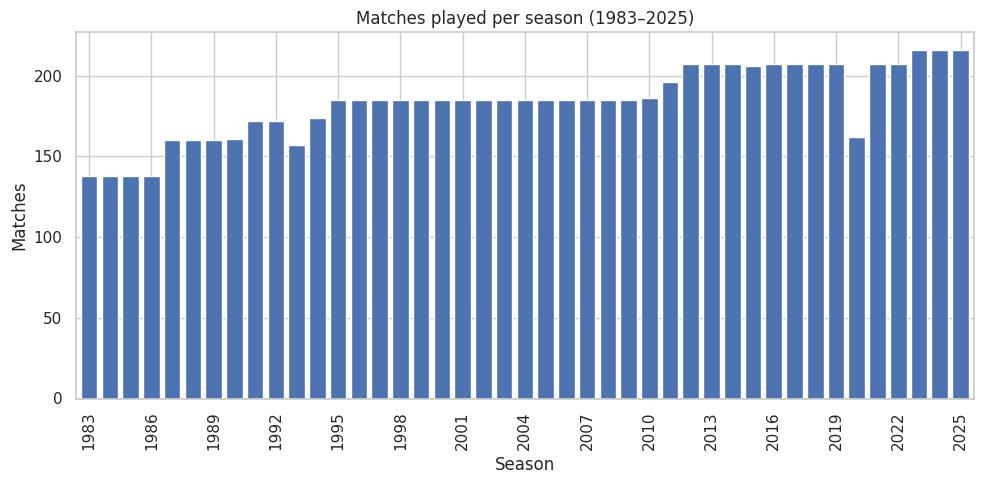

In [36]:
print('Season range        :', player_rounds.year.min(), '-', player_rounds.year.max())
print('Number of seasons   :', player_rounds.year.nunique())
print('Distinct teams (raw):', player_rounds.team.str.strip().nunique())
print('Distinct players    :', player_rounds.player_id.nunique())
print('Distinct matches (~):', len(team_matches) // 2, '(each match = 2 team-rows)')

games_per_season = team_matches.groupby('year').size() // 2
fig, ax = plt.subplots()
games_per_season.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Matches played per season (1983–2025)')
ax.set_ylabel('Matches'); ax.set_xlabel('Season')
ax.set_xticks(ax.get_xticks()[::3])
plt.tight_layout(); plt.savefig(FIGS/'01_matches_per_season.png', dpi=110); plt.show()


**Structural changes visible in the season-by-season match counts (flag these for modelling — a
team's 2025 opponent pool and season length are not the same as in 1990):**

- **League expansion**: from 14 teams (1983) up to 18 (from 2012, when GWS joined after Gold
  Coast in 2011) — more teams ⇒ more matches per season and new rivalries with no long history.
- **Team relocations / rebrands** show up as *different team names for what is effectively the
  same license*: Fitzroy Lions merged into **Brisbane Lions** (1997), South Melbourne became the
  **Sydney Swans** (before this data starts), **Footscray → Western Bulldogs** (1997, inconsistent
  spelling as `W. Bulldogs` in this dataset — see 1.3), **Brisbane Bears → Brisbane Lions** (1997
  merger with Fitzroy). Any "head-to-head history" feature needs to decide whether Fitzroy vs.
  Brisbane Lions history should count for a modern Brisbane Lions matchup.
- **COVID-19 (2020–21)**: shortened/rescheduled season, matches shifted out of home states,
  neutral venues — will show as anomalies in home-ground-advantage and travel features.
- **Grand Final replays** (drawn GFs in 1977-era rules did not apply after 1990, but this dataset
  still has replayed finals, e.g. 1990 QF and 2010 GF): the same `(team, opponent, round, year)`
  combination appears **twice** — this breaks any assumption that `(team, opponent, round, year)`
  is unique and must be handled by keeping `match_date` as a tiebreaker for those specific rows.
- **Rule changes affecting stats**: the "sub" bench-player rule (2011+), zones/6-6-6 rule (2019+),
  and simplified man-on-the-mark type changes affect scoring rates and disposal counts —
  historical averages spanning these eras aren't directly comparable without a season/era feature.


### 1.3 Data quality checks: missing values, duplicates, naming inconsistencies, outliers

In [37]:
# --- Missing values ---
print('=== % missing — player_rounds_raw (top 15) ===')
print((player_rounds.isnull().mean()*100).sort_values(ascending=False).head(15).round(1))
print()
print('=== % missing — team_matches_raw ===')
miss_t = (team_matches.isnull().mean()*100).sort_values(ascending=False)
print(miss_t[miss_t>0].round(1))


=== % missing — player_rounds_raw (top 15) ===
score                        100.0
brownlow_votes                40.3
goal_assist                   37.8
bounces                       35.5
hit_outs                      35.3
marks_inside_50               33.3
contested_marks               33.1
behinds                       29.6
goals                         27.3
percentage_of_game_played     25.4
clearances                    23.3
rebound_50s                   22.9
one_percenters                21.9
free_kicks_for                19.6
free_kicks_against            19.4
dtype: float64

=== % missing — team_matches_raw ===
round    4.5
crowd    2.5
dtype: float64


In [38]:
# The `score` column in player_rounds_raw is 100% null (dead column) - confirm and drop later
print('player_rounds_raw.score is fully null:', player_rounds['score'].isnull().all())

# Many player-level advanced stats (hit_outs, contested marks, brownlow_votes, bounces...) are
# NULL rather than 0 in early years -- this is NOT missing-at-random, it's a stat that AFL simply
# didn't track yet. Confirm:
by_year_null = player_rounds.groupby('year')[['hit_outs','contested_possessions','clangers']].apply(lambda d: d.isnull().mean())
print(by_year_null.loc[[1983, 1990, 1997, 2005, 2015, 2024]].round(2))


player_rounds_raw.score is fully null: True
      hit_outs  contested_possessions  clangers
year                                           
1983      0.57                   1.00      1.00
1990      0.84                   1.00      1.00
1997      0.81                   1.00      1.00
2005      0.45                   0.01      0.10
2015      0.03                   0.00      0.00
2024      0.89                   0.02      0.13


In [39]:
# --- Duplicates ---
print('Exact duplicate rows in player_rounds_raw:', player_rounds.duplicated().sum())
print('Exact duplicate rows in team_matches_raw :', team_matches.duplicated().sum())

dup_player_match = player_rounds.duplicated(subset=['player_id','match_date','opponent'], keep=False)
print('Player rows sharing the same player_id+match_date+opponent:', dup_player_match.sum())
player_rounds[dup_player_match].sort_values('player_id').head(6)[
    ['player_id','team','opponent','match_date','round','disposals','fantasy_points']]


Exact duplicate rows in player_rounds_raw: 0
Exact duplicate rows in team_matches_raw : 0
Player rows sharing the same player_id+match_date+opponent: 0


,player_id,team,opponent,match_date,round,disposals,fantasy_points


In [40]:
# --- Team / naming inconsistencies across the 3 tables ---
print('team_matches_raw.team_name raw variants   :', sorted(team_matches.team_name.unique()))
print()
print('team_matches_raw.opponent raw variants (mixed case!):')
print(sorted(set(team_matches.opponent.astype(str).str.strip().str.lower())
             - set(player_rounds.opponent.astype(str).str.strip().str.lower())))
print()
print('merged_players.team is lower-case, e.g.:', merged_players.team.unique()[:5].tolist())


team_matches_raw.team_name raw variants   : ['\t Adelaide Crows ', '\tBrisbane Bears', '\tBrisbane Lions', '\tCarlton Blues', '\tCollingwood Magpies', '\tEssendon Bombers', '\tFitzroy Lions', '\tFremantle Dockers', '\tGeelong Cats', '\tGold Coast Suns', '\tGreater Western Sydney Giants', '\tHawthorn Hawks', '\tMelbourne Demons', '\tNorth Melbourne Kangaroos', '\tPort Adelaide Power', '\tRichmond Tigers', '\tSt Kilda Saints', '\tSydney Swans', '\tW. Bulldogs', '\tWest Coast Eagles', ' Adelaide Crows ', 'Brisbane Bears', 'Brisbane Lions', 'Carlton Blues', 'Collingwood Magpies', 'Essendon Bombers', 'Fitzroy Lions', 'Fremantle Dockers', 'Geelong Cats', 'Gold Coast Suns', 'Greater Western Sydney Giants', 'Hawthorn Hawks', 'Melbourne Demons', 'North Melbourne Kangaroos', 'Port Adelaide Power', 'Richmond Tigers', 'St Kilda Saints', 'Sydney Swans', 'W. Bulldogs', 'West Coast Eagles']

team_matches_raw.opponent raw variants (mixed case!):
[]

merged_players.team is lower-case, e.g.: ['geelong c

**Naming issues found (and the fix used throughout this notebook):**

| Issue | Where | Fix |
|---|---|---|
| Leading/trailing whitespace (incl. a literal tab `\t`) around team names | `team_matches_raw.team_name` | `.str.strip()` |
| Mixed case: `'Geelong Cats'` vs `'geelong cats'` for the *same* team, sometimes within the same column | `team_matches_raw.team_name` / `.opponent` | `.str.lower()` for joins/grouping, keep a title-cased canonical name for display |
| `'W. Bulldogs'` vs `'Western Bulldogs'` for the same club | `team_matches_raw` only | explicit rename map `{'w. bulldogs': 'western bulldogs'}` |
| `merged_players.team` is lower-case throughout | `merged_players` | normalize with the same `.str.lower()` before joining to the other two tables |
| `match_date` can differ between `player_rounds_raw` and `team_matches_raw` for some rows (likely recording/date-definition quirks) | both | audit the discrepancy; use the canonical five-column key only where the parsed date agrees, and report unmatched rows rather than guessing |
| Same `(team, opponent, round, year, match_date)` appears twice for replayed finals (1990 QF, 2010 GF) | `team_matches_raw` | use `match_date` as part of the canonical match identity |


In [41]:
# --- Outliers / implausible values in key stats ---
key_stats = ['kicks','handballs','disposals','goals','tackles','fantasy_points']
print(player_rounds[key_stats].describe().T[['min','25%','50%','75%','max']])


                 min   25%   50%   75%    max
kicks            0.0   6.0   9.0  12.0   37.0
handballs        0.0   3.0   6.0   9.0   35.0
disposals       -5.0  10.0  14.0  20.0   54.0
goals            0.0   0.0   0.0   1.0   16.0
tackles          0.0   1.0   2.0   4.0   20.0
fantasy_points -10.0  45.0  64.0  84.0  210.0


In [42]:
# Negative disposals / fantasy points are impossible -- flag and quantify.
bad_disposals = player_rounds[player_rounds.disposals < 0].copy()
bad_fantasy   = player_rounds[player_rounds.fantasy_points < 0].copy()
bad_both = player_rounds[(player_rounds.disposals < 0) & (player_rounds.fantasy_points < 0)].copy()
bad_union = player_rounds[(player_rounds.disposals < 0) | (player_rounds.fantasy_points < 0)].copy()

print(f'Rows with negative disposals      : {len(bad_disposals):,}')
print(f'Rows with negative fantasy_points : {len(bad_fantasy):,}')
print(f'Rows negative in BOTH fields      : {len(bad_both):,}')
print(f'Rows negative in EITHER field     : {len(bad_union):,}')
print(f'Rows excluded from feature source : {len(bad_union):,}')

if len(bad_disposals):
    display(bad_disposals[['player_id','team','opponent','year','kicks','handballs','disposals','fantasy_points']].head())

# These are treated as data-quality errors and are excluded downstream;
# genuine high positive performances are not clipped.


Rows with negative disposals      : 722
Rows with negative fantasy_points : 167
Rows negative in BOTH fields      : 6
Rows negative in EITHER field     : 883
Rows excluded from feature source : 883


,player_id,team,opponent,year,kicks,handballs,disposals,fantasy_points
7,45747,Brisbane Lions,Adelaide Crows,2002,1.0,1.0,-3.0,20
18,45773,Sydney Swans,Adelaide Crows,1997,1.0,1.0,-3.0,2
19,45981,Richmond Tigers,Fitzroy Lions,1993,2.0,2.0,-1.0,14
26,45799,Hawthorn Hawks,Collingwood Magpies,2000,2.0,2.0,-1.0,28
56,45721,Melbourne Demons,Adelaide Crows,1998,2.0,1.0,-2.0,11


**Outlier verdict:** the *maximums* (16 goals, 54 disposals, 37 kicks in a game) are large but
plausible — AFL has genuine multi-goal-haul games and disposal-heavy midfielders, so these are
**kept**. The *negative* disposals/fantasy-points values are **data errors** (a handful of rows,
see count above total) and are excluded from any modelling table built in Task 4.


## 8. Versioned Feature Table & Feature Dictionary

The final feature table is the modelling contract.

Each important feature should have:
- a clear name,
- a definition,
- its source columns,
- its historical window,
- and an explicit statement that it is available before prediction time.

Current-match outcomes/statistics are kept separate from lagged predictive features.

In [43]:
N_BAD_ROWS = len(bad_disposals) + len(bad_fantasy[bad_fantasy.disposals >= 0])
print('Rows to exclude from feature table:', N_BAD_ROWS)

Rows to exclude from feature table: 821


### 2.2 "Top player" — target definitions

The notebook defines three complementary player-level targets/metrics:

| Version | Definition | Exact formula | Aggregation level |
|---|---|---|---|
| **Top disposal-getter** | Player with the highest supplied disposal total | `disposals` (source field; not reconstructed from kicks + handballs) | player-match; can be aggregated by round/season |
| **Top goal-kicker** | Player with the highest supplied goal total | `goals` | player-match; can be aggregated by round/season |
| **Composite performance metric** | A transparent, reproducible diagnostic score used to compare the supplied `fantasy_points` field | `3*kicks + 2*handballs + 3*marks + 4*tackles + 6*goals + behinds + hit_outs + free_kicks_for - 3*free_kicks_against + 5*clearances - 2*clangers` | player-match; can be aggregated by round/season |

**Important interpretation:** `fantasy_points` is a supplied source field and is **not overwritten** by the custom score. The custom score is only a transparent validation/diagnostic metric. Because the source data does not provide a documented official formula for its `fantasy_points` field, this notebook does not claim the custom score is the official AFL Fantasy formula.

**Data-quality contract:** the supplied `disposals` field is treated as authoritative. The notebook reports the empirical mismatch between `disposals` and `kicks + handballs` rather than silently reconstructing disposals.


## 4. Prediction Targets & Data Dictionary

The target definitions in this section are the contract for Day 2.

### Match target
`match_result_3way` = `HOME_WIN`, `AWAY_WIN`, or `DRAW`.

### Player target candidates
We examine:
- disposal leadership,
- goal-kicking leadership,
- fantasy-style performance.

Where a composite score is used, its formula is explicitly stated and distinguished from any official AFL fantasy scoring system.

In [44]:
# Validate target inputs and numeric stat integrity before building labels.

required_formula_cols = [
    'kicks', 'handballs', 'disposals', 'marks', 'tackles',
    'goals', 'behinds', 'hit_outs', 'fantasy_points'
]
missing_formula_cols = [c for c in required_formula_cols if c not in pr.columns]
if missing_formula_cols:
    raise KeyError(f"Required player-stat columns missing: {missing_formula_cols}")

# Explicitly coerce a local calculation copy as a second defensive layer.
calc = pr[required_formula_cols].apply(pd.to_numeric, errors='coerce')

chk = calc.dropna(subset=['kicks', 'handballs', 'disposals'])
mismatch_mask = (
    chk['kicks'] + chk['handballs'] != chk['disposals']
)
mismatch = mismatch_mask.mean()
print(
    f'% of complete player rows where disposals != kicks+handballs: '
    f'{mismatch*100:.2f}%'
)

# Show whether the mismatch is concentrated in particular seasons.
mismatch_rows = pr.loc[chk.index[mismatch_mask]].copy()
if len(mismatch_rows):
    print('\nMismatch rows by season (top 15):')
    print(mismatch_rows.groupby('year').size().sort_values(ascending=False).head(15))

# Explicitly validate the supplied fantasy_points column against a transparent custom composite.
# This is a diagnostic, not a claim that it is the official AFL Fantasy formula.
custom = (
    3.0 * calc['kicks'].fillna(0)
    + 2.0 * calc['handballs'].fillna(0)
    + 3.0 * calc['marks'].fillna(0)
    + 4.0 * calc['tackles'].fillna(0)
    + 6.0 * calc['goals'].fillna(0)
    + 1.0 * calc['behinds'].fillna(0)
    + 1.0 * calc['hit_outs'].fillna(0)
    + 1.0 * pd.to_numeric(
        pr.get('free_kicks_for', pd.Series(index=pr.index, dtype='float64')),
        errors='coerce'
    ).fillna(0)
    - 3.0 * pd.to_numeric(
        pr.get('free_kicks_against', pd.Series(index=pr.index, dtype='float64')),
        errors='coerce'
    ).fillna(0)
    + 5.0 * pd.to_numeric(
        pr.get('clearances', pd.Series(index=pr.index, dtype='float64')),
        errors='coerce'
    ).fillna(0)
    - 2.0 * pd.to_numeric(
        pr.get('clangers', pd.Series(index=pr.index, dtype='float64')),
        errors='coerce'
    ).fillna(0)
)

validation = pd.DataFrame({
    'custom_score': custom,
    'fantasy_points': calc['fantasy_points']
}).dropna()

if len(validation) >= 2:
    print(
        'Custom-score vs supplied fantasy_points correlation: '
        f"{validation['custom_score'].corr(validation['fantasy_points']):.3f}"
    )
else:
    print('Custom-score validation skipped: fewer than 2 complete rows.')

# One match-level target row comes from each home team row.
home_rows = tm[tm.home_away == 'H'].copy()

def match_outcome_from_home(row):
    if row.result == 'D':
        return 'DRAW'
    return 'HOME_WIN' if row.result == 'W' else 'AWAY_WIN'

home_rows['match_result_3way'] = home_rows.apply(match_outcome_from_home, axis=1)
home_rows['margin_home'] = home_rows['team_score'] - home_rows['opponent_score']

draws = (home_rows['match_result_3way'] == 'DRAW').sum()
matches = len(home_rows)
print(home_rows['match_result_3way'].value_counts())
print(f'Match-level draw rate: {draws / matches * 100:.2f}% ({draws:,}/{matches:,})')


% of complete player rows where disposals != kicks+handballs: 7.97%

Mismatch rows by season (top 15):
year
2025    804
2023    779
2016    772
2022    772
2005    767
2002    746
2017    743
2024    740
2015    732
2021    727
2003    719
2007    718
2004    703
2006    692
2018    681
dtype: int64
Custom-score vs supplied fantasy_points correlation: 0.961
match_result_3way
HOME_WIN    4669
AWAY_WIN    3170
DRAW          65
Name: count, dtype: int64
Match-level draw rate: 0.82% (65/7,904)


---
## Task 3: Exploratory Data Analysis


### 3.1 Team win rates over time

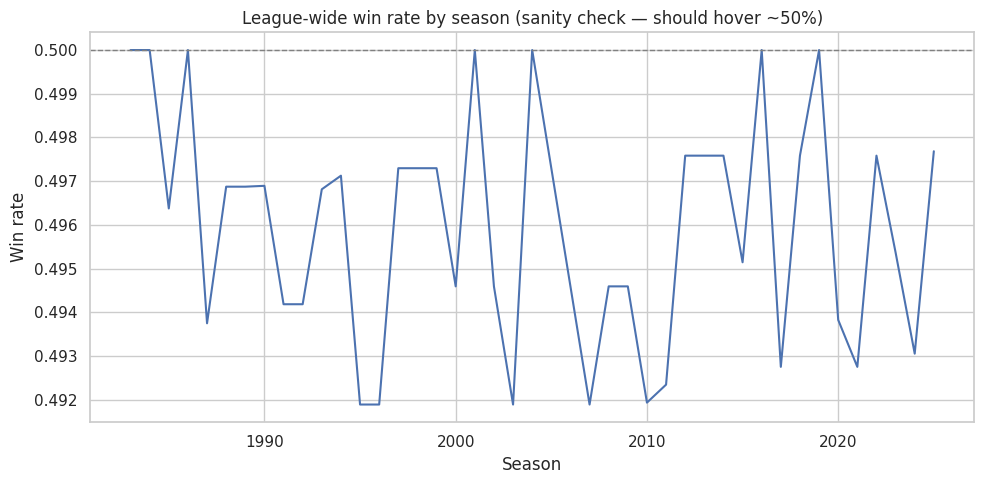

In [45]:
tm2 = tm.copy()
tm2['team_n'] = norm_team(tm2['team_name'])
tm2['is_win'] = (tm2['result'] == 'W').astype(int)

win_rate_by_year = tm2.groupby('year')['is_win'].mean()

fig, ax = plt.subplots()
win_rate_by_year.plot(ax=ax)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
ax.set_title('League-wide win rate by season (sanity check — should hover ~50%)')
ax.set_ylabel('Win rate'); ax.set_xlabel('Season')
plt.tight_layout(); plt.savefig(FIGS/'02_league_win_rate.png', dpi=110); plt.show()


team_n
geelong cats                     0.611
hawthorn hawks                   0.583
collingwood magpies              0.542
port adelaide power              0.534
essendon bombers                 0.530
west coast eagles                0.523
sydney swans                     0.522
adelaide crows                   0.517
brisbane lions                   0.510
western bulldogs                 0.503
north melbourne kangaroos        0.477
carlton blues                    0.474
greater western sydney giants    0.474
fremantle dockers                0.458
melbourne demons                 0.440
st kilda saints                  0.433
richmond tigers                  0.428
fitzroy lions                    0.362
brisbane bears                   0.324
gold coast suns                  0.318
Name: is_win, dtype: float64


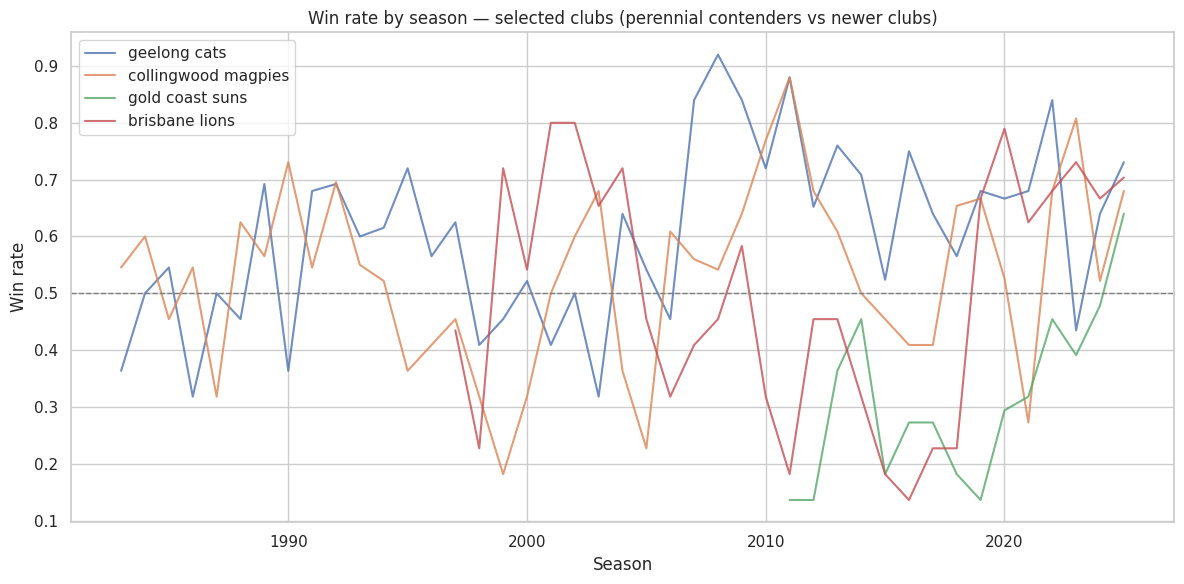

In [46]:
# Execution-order guard
if 'tm2' not in globals():
    raise RuntimeError(
        "tm2 is not defined. Run the cleaned team-match preparation cell first."
    )

# Per-team win rate over time -- who's been dominant across eras
top_teams = tm2.groupby('team_n')['is_win'].mean().sort_values(ascending=False)
print(top_teams.round(3))

pivot = tm2.pivot_table(index='year', columns='team_n', values='is_win', aggfunc='mean')
fig, ax = plt.subplots(figsize=(12,6))
for team in ['geelong cats','collingwood magpies','gold coast suns','brisbane lions']:
    if team in pivot.columns:
        ax.plot(pivot.index, pivot[team], label=team, alpha=0.8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
ax.legend(); ax.set_title('Win rate by season — selected clubs (perennial contenders vs newer clubs)')
ax.set_ylabel('Win rate'); ax.set_xlabel('Season')
plt.tight_layout(); plt.savefig(FIGS/'03_team_win_rate_trend.png', dpi=110); plt.show()


### 3.2 Home-ground advantage

Home win rate, all designated-home matches     : 59.1%
Home win rate, non-neutral matches             : 59.1%
Away win rate                                  : 40.1%
Flagged neutral/obvious non-home-ground matches: 262


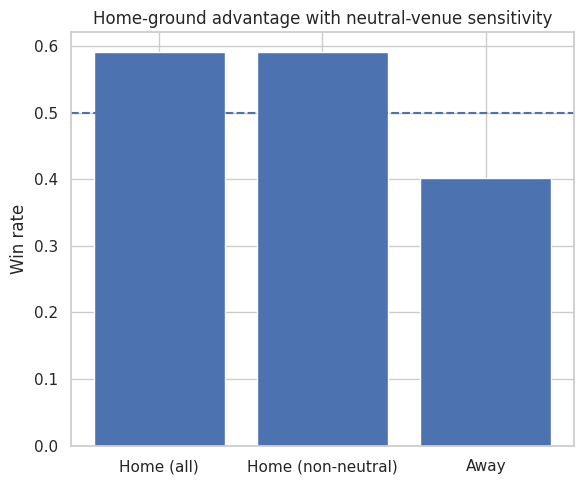

In [47]:
# Execution-order guard
if 'tm2' not in globals():
    raise RuntimeError(
        "tm2 is not defined. Run the cleaned team-match preparation cell first."
    )

# Home-ground advantage must not treat obvious neutral venues as home grounds.
# Venue-state mappings are intentionally explicit and conservative; unknown venues remain NaN.
VENUE_STATE_MAP = {
    'mcg': 'VIC', 'melbourne cricket ground': 'VIC',
    'marvel stadium': 'VIC', 'docklands': 'VIC', 'etihad stadium': 'VIC',
    'mcg, melbourne': 'VIC', 'waverley': 'VIC', 'princes park': 'VIC',
    'gabba': 'QLD', 'brisbane cricket ground': 'QLD', 'the gabba': 'QLD',
    'sydney cricket ground': 'NSW', 'scg': 'NSW', 'sydney showground': 'NSW',
    'stadium australia': 'NSW', 'anz stadium': 'NSW', 'giants stadium': 'NSW',
    'adelaide oval': 'SA', 'football park': 'SA', 'aami stadium': 'SA',
    'subiaco': 'WA', 'optus stadium': 'WA', 'perth stadium': 'WA',
    'carrara': 'QLD', 'metricon stadium': 'QLD', 'heritage bank stadium': 'QLD',
    'engie stadium': 'NSW', 'sydney showground stadium': 'NSW',
    'kardinia park': 'VIC', 'simonds stadium': 'VIC', 'gmhba stadium': 'VIC',
    'manuka oval': 'ACT', 'canberra': 'ACT',
    'tassie': 'TAS', 'blundstone arena': 'TAS', 'bellerive': 'TAS',
    'north hobart oval': 'TAS', 'launceston': 'TAS',
}
TEAM_STATE_MAP = {
    'adelaide crows':'SA', 'brisbane bears':'QLD', 'brisbane lions':'QLD',
    'carlton blues':'VIC', 'collingwood magpies':'VIC', 'essendon bombers':'VIC',
    'fremantle dockers':'WA', 'fitzroy lions':'VIC', 'geelong cats':'VIC',
    'gold coast suns':'QLD', 'gws giants':'NSW', 'greater western sydney giants':'NSW',
    'hawthorn hawks':'VIC', 'melbourne demons':'VIC', 'north melbourne kangaroos':'VIC',
    'port adelaide power':'SA', 'richmond tigers':'VIC', 'st kilda saints':'VIC',
    'sydney swans':'NSW', 'university':'VIC', 'west coast eagles':'WA',
    'western bulldogs':'VIC', 'footy club':'VIC',
}
def map_state(series, mapping):
    return series.astype('string').str.lower().str.strip().map(mapping)

tm2['venue_state'] = map_state(tm2['venue'], VENUE_STATE_MAP)
tm2['team_state'] = map_state(tm2['team_n'], TEAM_STATE_MAP)
tm2['opp_state'] = map_state(tm2['opp_n'], TEAM_STATE_MAP)
tm2['is_interstate'] = (tm2['venue_state'].notna() & tm2['team_state'].notna() &
                        (tm2['venue_state'] != tm2['team_state'])).astype('int')
tm2['is_neutral_venue'] = (
    tm2['round'].astype('string').str.upper().str.contains('GF|GRAND', regex=True, na=False)
    | (
        tm2['venue_state'].notna() & tm2['team_state'].notna() & tm2['opp_state'].notna()
        & (tm2['venue_state'] != tm2['team_state'])
        & (tm2['venue_state'] != tm2['opp_state'])
      )
)
home_only = tm2[tm2.home_away == 'H'].copy()
non_neutral = home_only[~home_only['is_neutral_venue']]

home_win_rate_all = (home_only['result'] == 'W').mean()
home_win_rate_non_neutral = (non_neutral['result'] == 'W').mean()
away_win_rate = (tm2[tm2.home_away == 'A']['result'] == 'W').mean()
print(f'Home win rate, all designated-home matches     : {home_win_rate_all*100:.1f}%')
print(f'Home win rate, non-neutral matches             : {home_win_rate_non_neutral*100:.1f}%')
print(f'Away win rate                                  : {away_win_rate*100:.1f}%')
print(f'Flagged neutral/obvious non-home-ground matches: {tm2["is_neutral_venue"].sum():,}')

fig, ax = plt.subplots(figsize=(6,5))
ax.bar(['Home (all)','Home (non-neutral)','Away'], [home_win_rate_all, home_win_rate_non_neutral, away_win_rate])
ax.axhline(0.5, linestyle='--')
ax.set_ylabel('Win rate'); ax.set_title('Home-ground advantage with neutral-venue sensitivity')
plt.tight_layout(); plt.savefig(FIGS/'04_home_advantage.png', dpi=110); plt.show()


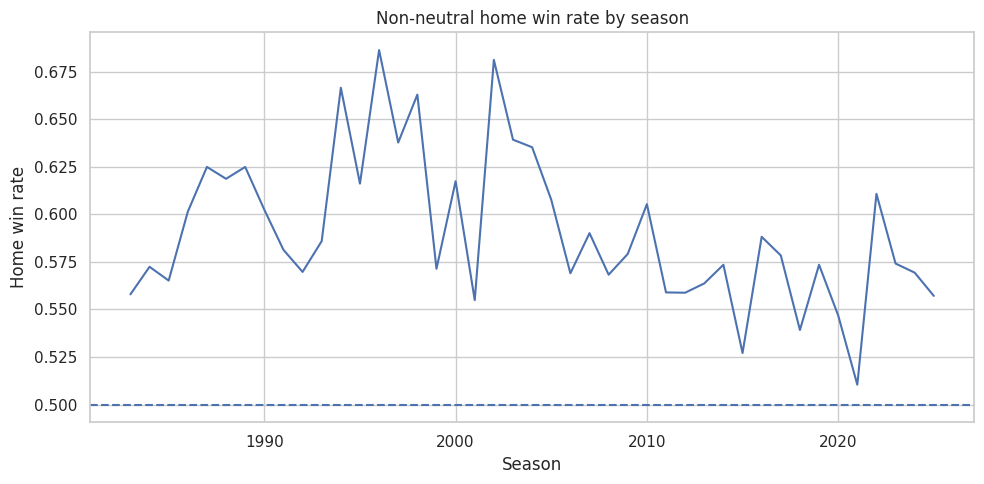

Non-neutral home-win rate: 0.591
Match-level bootstrap 95% CI: [0.580, 0.602]


In [48]:
# Execution-order guard
if 'tm2' not in globals():
    raise RuntimeError(
        "tm2 is not defined. Run the cleaned team-match preparation cell first."
    )

home_adv_by_year = (
    tm2[(tm2.home_away == 'H') & (~tm2['is_neutral_venue'])]
    .groupby('year')['result'].apply(lambda s: (s == 'W').mean())
)
fig, ax = plt.subplots()
home_adv_by_year.plot(ax=ax)
ax.axhline(0.5, linestyle='--')
ax.set_title('Non-neutral home win rate by season')
ax.set_ylabel('Home win rate'); ax.set_xlabel('Season')
plt.tight_layout(); plt.savefig(FIGS/'05_home_advantage_trend.png', dpi=110); plt.show()


# Match-level bootstrap CI for the non-neutral home-win rate.
# This uses ONLY actual home-team match rows, so each observation is exactly one match.
# The statistic is the probability that the designated home team wins a non-neutral match.
home_outcomes = (
    tm2[
        (tm2['home_away'] == 'H') &
        (~tm2['is_neutral_venue'])
    ]['result']
    .eq('W')
    .astype(int)
    .dropna()
)

home_win_rate = home_outcomes.mean()
rng = np.random.default_rng(42)
values = home_outcomes.to_numpy()
boot = np.array([
    rng.choice(values, size=len(values), replace=True).mean()
    for _ in range(2000)
])
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f'Non-neutral home-win rate: {home_win_rate:.3f}')
print(f'Match-level bootstrap 95% CI: [{lo:.3f}, {hi:.3f}]')


### 3.3 Player-level distributions for the "top player" metrics

In [49]:
# Historical leaders -- career totals across the whole dataset window.
career_goals = player_rounds.groupby('player_id')['goals'].sum().sort_values(ascending=False).head(10)
career_disp  = player_rounds.groupby('player_id')['disposals'].sum().sort_values(ascending=False).head(10)

# Attach names via merged_players (id == player_id). Keep the numeric ID when a name is unavailable.
name_map = (
    merged_players[['id','player_full_name']]
    .dropna(subset=['id'])
    .drop_duplicates('id')
    .set_index('id')['player_full_name']
)
def display_player_leaders(series):
    labels = [
        str(name_map.loc[pid]) if pid in name_map.index and pd.notna(name_map.loc[pid])
        else f'UNRESOLVED_PLAYER_ID_{pid}'
        for pid in series.index
    ]
    out = series.copy()
    out.index = labels
    return out

print('Top 10 career goal-kickers (this dataset window, 1983-2025):')
display(display_player_leaders(career_goals))
print()
print('Top 10 career disposal-getters:')
display(display_player_leaders(career_disp))

unresolved_goals = [pid for pid in career_goals.index if pid not in name_map.index]
unresolved_disp = [pid for pid in career_disp.index if pid not in name_map.index]
print(f'Unresolved IDs among goal-kicker leaders: {unresolved_goals}')
print(f'Unresolved IDs among disposal leaders: {unresolved_disp}')


Top 10 career goal-kickers (this dataset window, 1983-2025):


,goals
Tony_Lockett,1360.0
Lance_Franklin,1066.0
Matthew_Lloyd0,926.0
Matthew_Richardson,800.0
Tom_Hawkins,796.0
Jack_Riewoldt,787.0
Saverio_Rocca,748.0
Barry_Hall,746.0
Jeremy_Cameron,736.0
Wayne_Carey,727.0



Top 10 career disposal-getters:


,disposals
Scott_Pendlebury,10502.0
Robert_Harvey,9267.0
Brent_Harvey,8815.0
Gary_Ablett1,8686.0
Travis_Boak,8620.0
Craig_Bradley,8571.0
Joel_Selwood,8489.0
Sam_Mitchell,8335.0
Scott_West,8016.0
Patrick_Dangerfield,7995.0


Unresolved IDs among goal-kicker leaders: []
Unresolved IDs among disposal leaders: []


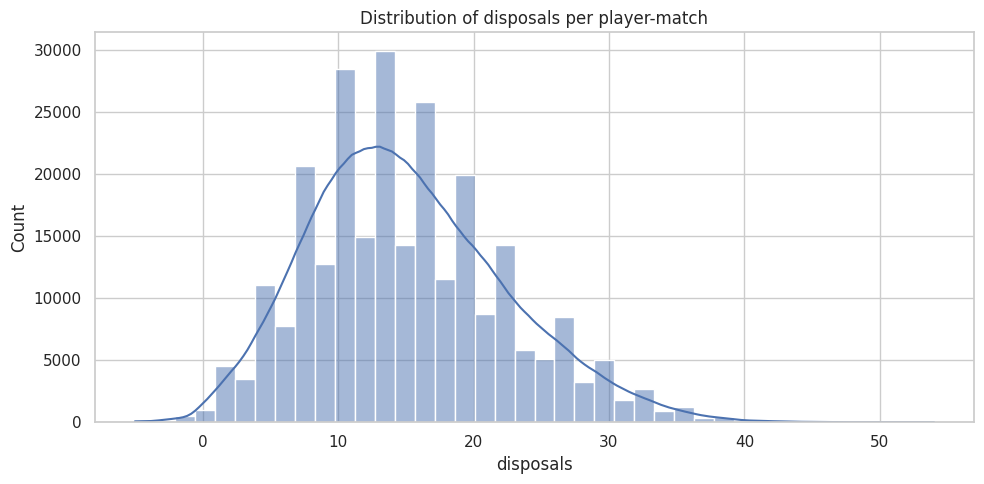

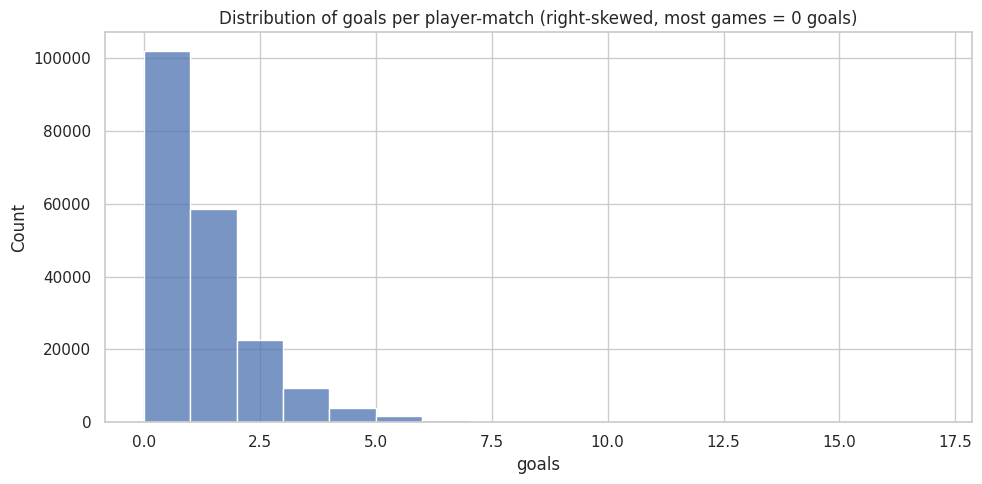

In [50]:
fig, ax = plt.subplots()
sns.histplot(player_rounds['disposals'].dropna(), bins=40, ax=ax, kde=True)
ax.set_title('Distribution of disposals per player-match')
plt.tight_layout(); plt.savefig(FIGS/'06_disposals_dist.png', dpi=110); plt.show()

fig, ax = plt.subplots()
sns.histplot(player_rounds['goals'].dropna(), bins=range(0,18), ax=ax)
ax.set_title('Distribution of goals per player-match (right-skewed, most games = 0 goals)')
plt.tight_layout(); plt.savefig(FIGS/'07_goals_dist.png', dpi=110); plt.show()


In [51]:
# Week-to-week consistency: coefficient of variation of disposals for players with >=50 games
games_per_player = player_rounds.groupby('player_id').size()
regulars = games_per_player[games_per_player >= 50].index
consistency = (player_rounds[player_rounds.player_id.isin(regulars)]
               .groupby('player_id')['disposals']
               .agg(['mean','std']))
consistency['cv'] = consistency['std'] / consistency['mean']
print('Most consistent regulars (lowest coefficient of variation in disposals):')
print(consistency.sort_values('cv').head(8).round(2))
print()
print('Most volatile regulars (highest CV):')
print(consistency.sort_values('cv', ascending=False).head(8).round(2))


Most consistent regulars (lowest coefficient of variation in disposals):
            mean   std    cv
player_id                   
45112      28.03  5.96  0.21
44966      21.37  4.55  0.21
45167      27.42  5.92  0.22
43646      26.35  5.82  0.22
44910      28.64  6.43  0.22
44491      22.05  5.05  0.23
44630      28.13  6.58  0.23
43307      24.55  5.75  0.23

Most volatile regulars (highest CV):
           mean   std    cv
player_id                  
44447      1.36  3.25  2.39
44265      3.16  4.02  1.27
44304      3.32  3.96  1.19
44577      6.52  7.38  1.13
44564      3.80  4.18  1.10
45617      6.16  5.95  0.97
45071      4.61  4.27  0.93
43615      4.97  4.57  0.92


### 3.4 Additional relationships relevant to prediction (5+ visualizations, continued)

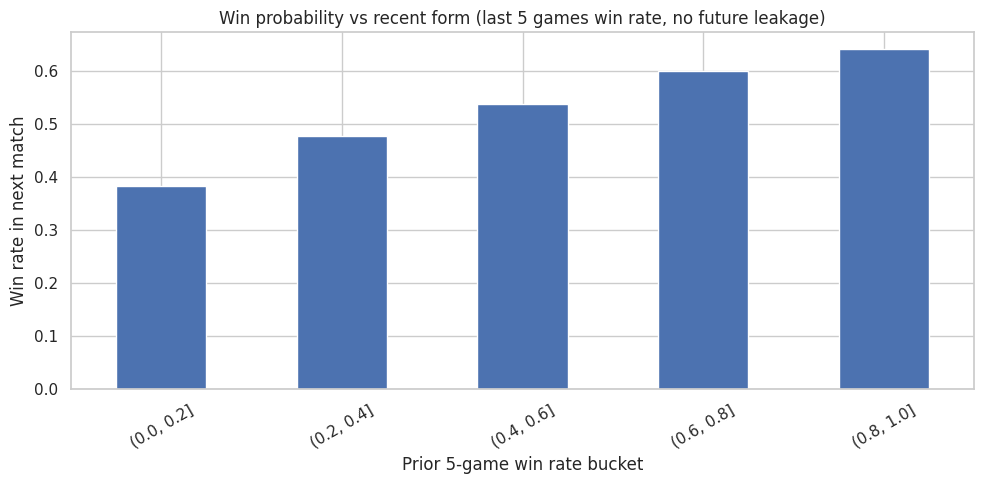

In [52]:
# Leakage control: shift by one match so the current match never enters its own historical feature.
# Execution-order guard
if 'tm2' not in globals():
    raise RuntimeError(
        "tm2 is not defined. Run the cleaned team-match preparation cell first."
    )

# Recent form vs win probability -- does a team's last-5-game win rate predict the next result?
tm3 = tm2.sort_values(['team_n','year','match_date']).copy()
tm3['prev5_win_rate'] = (tm3.groupby('team_n')['is_win']
                          .transform(lambda s: s.shift(1).rolling(5, min_periods=3).mean()))
form_bins = pd.cut(tm3['prev5_win_rate'], bins=[0,0.2,0.4,0.6,0.8,1.0])
form_vs_win = tm3.groupby(form_bins, observed=True)['is_win'].mean()

fig, ax = plt.subplots()
form_vs_win.plot(kind='bar', ax=ax)
ax.set_title('Win probability vs recent form (last 5 games win rate, no future leakage)')
ax.set_ylabel('Win rate in next match'); ax.set_xlabel('Prior 5-game win rate bucket')
plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig(FIGS/'08_form_vs_win.png', dpi=110); plt.show()


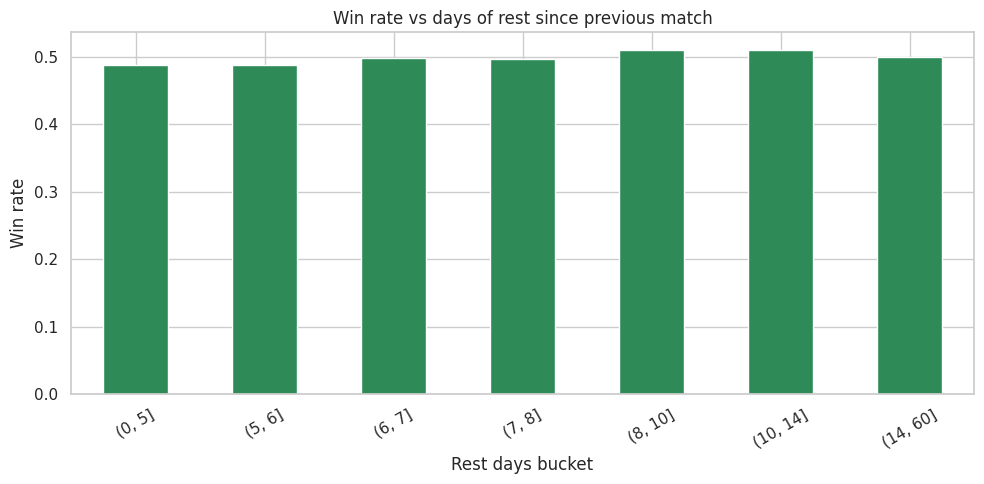

In [53]:
# Rest days between matches -- does more rest correlate with winning?
tm3['match_date'] = pd.to_datetime(tm3['match_date'])
tm3['prev_match_date'] = tm3.groupby('team_n')['match_date'].shift(1)
tm3['rest_days'] = (tm3['match_date'] - tm3['prev_match_date']).dt.days

rest_bins = pd.cut(tm3['rest_days'], bins=[0,5,6,7,8,10,14,60])
rest_vs_win = tm3.groupby(rest_bins, observed=True)['is_win'].mean()

fig, ax = plt.subplots()
rest_vs_win.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Win rate vs days of rest since previous match')
ax.set_ylabel('Win rate'); ax.set_xlabel('Rest days bucket')
plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig(FIGS/'09_rest_vs_win.png', dpi=110); plt.show()


/tmp/ipykernel_682/2999465420.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prof_valid['position_guess'] = prof_valid.apply(guess_position, axis=1)


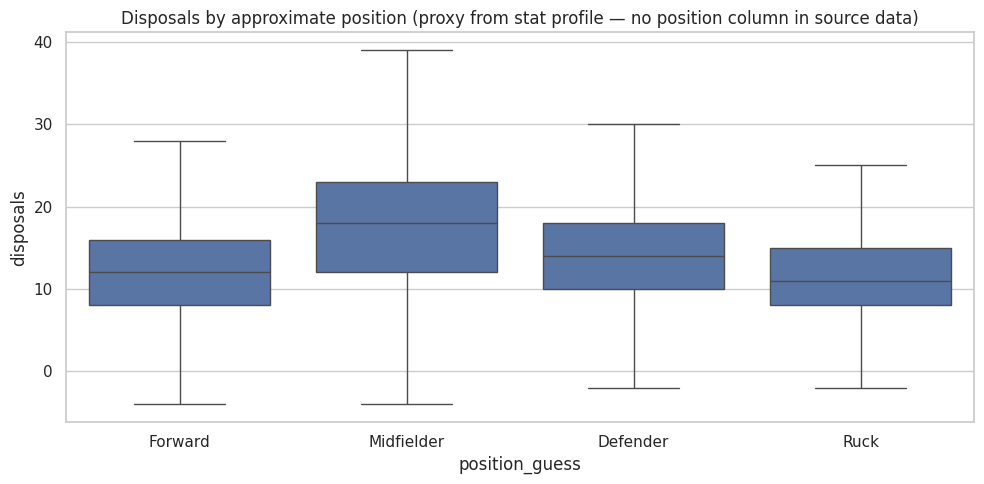

NOTE: this is a heuristic position proxy, not ground-truth position data — flagged for Day 2.


In [54]:
# Position-based differences: approximate position via stat profile
# (no explicit position column exists, so we proxy: high hit_outs => ruck, high rebound_50s => defender,
#  high inside_50s+clearances => midfielder, high goals+marks_inside_50 => forward)
prof = player_rounds.groupby('player_id')[['hit_outs','rebound_50s','clearances','inside_50s',
                                             'goals','marks_inside_50','disposals']].mean()
def guess_position(row):
    scores = {
        'Ruck': row['hit_outs'],
        'Defender': row['rebound_50s'],
        'Midfielder': row['clearances'] + row['inside_50s'],
        'Forward': row['goals']*3 + row['marks_inside_50'],
    }
    return max(scores, key=lambda k: (scores[k] if pd.notnull(scores[k]) else -1))
prof_valid = prof.dropna(subset=['hit_outs','rebound_50s','clearances','inside_50s','goals','marks_inside_50'], how='all')
prof_valid['position_guess'] = prof_valid.apply(guess_position, axis=1)

pos_disposals = player_rounds.merge(prof_valid[['position_guess']], on='player_id', how='inner')
fig, ax = plt.subplots()
sns.boxplot(data=pos_disposals, x='position_guess', y='disposals', ax=ax, showfliers=False)
ax.set_title('Disposals by approximate position (proxy from stat profile — no position column in source data)')
plt.tight_layout(); plt.savefig(FIGS/'10_position_disposals.png', dpi=110); plt.show()
print('NOTE: this is a heuristic position proxy, not ground-truth position data — flagged for Day 2.')


### 3.5 Travel / interstate effect

The travel feature is deliberately simple and auditable: `is_interstate` = 1 when the team's
mapped home state differs from the venue state. Unknown venue/team mappings stay missing rather
than being guessed. This is a contextual feature, not proof of a causal travel effect.


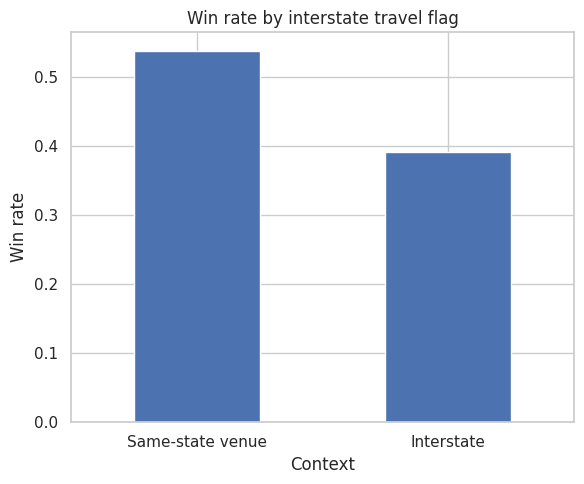

is_interstate
same_state    8304
interstate    3382
dtype: int64


In [55]:
# Execution-order guard
if 'tm2' not in globals():
    raise RuntimeError(
        "tm2 is not defined. Run the cleaned team-match preparation cell first."
    )

travel_tm = tm2.copy()
travel_tm = travel_tm[travel_tm['venue_state'].notna() & travel_tm['team_state'].notna()].copy()
travel_vs_win = travel_tm.groupby('is_interstate')['is_win'].mean()

fig, ax = plt.subplots(figsize=(6,5))
travel_vs_win.rename(index={0:'Same-state venue',1:'Interstate'}).plot(kind='bar', ax=ax)
ax.set_ylabel('Win rate'); ax.set_xlabel('Context')
ax.set_title('Win rate by interstate travel flag')
plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(FIGS/'11_travel_vs_win.png', dpi=110); plt.show()

print(travel_tm.groupby('is_interstate').size().rename(index={0:'same_state',1:'interstate'}))


---
## Task 4: Feature Engineering for Prediction

**Leakage rule used throughout this section:** every rolling/aggregate feature for a match at time
`t` is computed using only rows with a match date/round **strictly before** `t` for that entity
(`.shift(1)` before any `.rolling()`), and the split (Task 5) trains only on seasons/rounds that
precede the hold-out period.


**Player-target note:** `player_feature_table` retains the current-match supplied `disposals`, `goals`, and `fantasy_points` because these are candidate target variables for Day 2. The lagged `player_avg_*` columns are the pre-match predictive features. Current-match player outputs must never be used as predictors for the same match.


### 4.1 Build a clean match-level table (1 row per match) as the base for features

### Replay-safe match merge
The **canonical match merge uses five keys**: `team_n`, `opp_n`, `round`, `year`, and `match_date_key`. The original
four-column candidate key is not used anywhere in the match-building logic. Source dates are retained separately
as `match_date_home` and `match_date_away` and must agree exactly after the merge. `validate='one_to_one'` plus a
unique `match_key` assertion guards against replay cross-products and duplicate match rows.

In [56]:
# Execution-order guard
if 'tm2' not in globals():
    raise RuntimeError(
        "tm2 is not defined. Run the cleaned team-match preparation cell first."
    )

home = tm2[tm2.home_away == 'H'].copy()
away = tm2[tm2.home_away == 'A'].copy()

# Canonical match identity: BOTH sides must carry the same date in the join key.
# We keep the original dates separately so we can verify the match pairing after the merge.
home = home.rename(columns={'match_date': 'match_date_home'})
away = away.rename(columns={'match_date': 'match_date_away'})
home['match_date_key'] = pd.to_datetime(home['match_date_home'])
away['match_date_key'] = pd.to_datetime(away['match_date_away'])

# Swap the away perspective so the home row's opponent becomes the away team's team.
away_ren = away.rename(columns={'team_n':'opp_n','opp_n':'team_n'})
match_merge_keys = ['team_n', 'opp_n', 'round', 'year', 'match_date_key']

match_base = home.merge(
    away_ren,
    on=match_merge_keys,
    suffixes=('_home','_away'),
    how='inner',
    validate='one_to_one'
)

# The source dates must agree exactly for a real match pair.
match_base['match_date_home'] = pd.to_datetime(match_base['match_date_home'])
match_base['match_date_away'] = pd.to_datetime(match_base['match_date_away'])
assert match_base['match_date_home'].eq(match_base['match_date_away']).all(), \
    'Home and away source dates disagree after the canonical 5-column merge.'

match_base['match_date'] = match_base['match_date_home']
match_base['match_key'] = (
    match_base['year'].astype(str) + '_' + match_base['round'].astype(str)
    + '_' + match_base['team_n'] + '_vs_' + match_base['opp_n']
    + '_' + match_base['match_date'].dt.strftime('%Y-%m-%d')
)
assert match_base['match_key'].duplicated().sum() == 0, 'match_key must be unique.'
assert len(match_base) == home['match_date_home'].nunique() or len(match_base) == len(home), (
    "Replay-safe merge lost or multiplied home-side matches; inspect canonical keys and dates."
)
match_base['match_result_3way'] = np.select(
    [match_base['result_home'] == 'W', match_base['result_home'] == 'L'],
    ['HOME_WIN', 'AWAY_WIN'], default='DRAW'
)
match_base['margin'] = match_base['team_score_home'] - match_base['team_score_away']
match_base = match_base.sort_values('match_date').reset_index(drop=True)
print(f'Match-level rows: {len(match_base):,}')
display(match_base[['match_key','match_date','team_n','opp_n','venue_home','match_result_3way','margin']].head())

Match-level rows: 7,904


,match_key,match_date,team_n,opp_n,venue_home,match_result_3way,margin
0,1983_1.0_melbourne demons_vs_collingwood magpi...,1983-03-26,melbourne demons,collingwood magpies,Melbourne Cricket Ground,AWAY_WIN,-10
1,1983_1.0_carlton blues_vs_richmond tigers_1983...,1983-03-26,carlton blues,richmond tigers,Princes Park,HOME_WIN,60
2,1983_1.0_fitzroy lions_vs_hawthorn hawks_1983-...,1983-03-26,fitzroy lions,hawthorn hawks,Junction Oval,AWAY_WIN,-19
3,1983_1.0_north melbourne kangaroos_vs_st kilda...,1983-03-26,north melbourne kangaroos,st kilda saints,Aegis Park,HOME_WIN,13
4,1983_1.0_geelong cats_vs_western bulldogs_1983...,1983-03-26,geelong cats,western bulldogs,Waverley Park,HOME_WIN,31


### 4.2 Rolling / form features (team win streaks, last-N average scores, last-N player output)

All computed with `.shift(1)` first so the feature for a match never includes that match's own
result.

In [57]:
# Leakage control: shift by one match so the current match never enters its own historical feature.
# Execution-order guard
if 'match_base' not in globals():
    raise RuntimeError(
        "match_base is not defined. Run the match-level assembly cell before this cell."
    )

# Build a long team-perspective table (2 rows per match).
require_columns(match_base, ['year', 'round', 'match_date'], 'match_base')
# Every predictive aggregate below uses only prior rows.
home_side = match_base.rename(columns={
    'team_n':'team', 'opp_n':'opponent', 'team_score_home':'team_score', 'team_score_away':'opp_score',
    'venue_home':'venue', 'team_state_home':'team_state', 'venue_state_home':'venue_state',
    'is_interstate_home':'is_interstate', 'is_neutral_venue_home':'is_neutral_venue'
}).copy()
home_side['is_home'] = 1
home_side['team_win'] = (home_side['match_result_3way'] == 'HOME_WIN').astype(int)

away_side = match_base.rename(columns={
    'opp_n':'team', 'team_n':'opponent', 'team_score_away':'team_score', 'team_score_home':'opp_score',
    'venue_home':'venue', 'team_state_away':'team_state', 'venue_state_away':'venue_state',
    'is_interstate_away':'is_interstate', 'is_neutral_venue_away':'is_neutral_venue'
}).copy()
away_side['is_home'] = 0
away_side['team_win'] = (away_side['match_result_3way'] == 'AWAY_WIN').astype(int)

context_cols = ['match_key','match_date','year','round','team','opponent','venue','team_state','venue_state',
                'is_interstate','is_neutral_venue','is_home','team_win','team_score','opp_score']
team_long = pd.concat([
    home_side[context_cols],
    away_side[context_cols]
], ignore_index=True).sort_values(['team','match_date','match_key']).reset_index(drop=True)

g = team_long.groupby('team', sort=False)
team_long['prev_win'] = g['team_win'].shift(1)

# Correct consecutive-win streak: current streak entering the match.
def prior_win_streak(s):
    vals = s.fillna(0).astype(int).to_numpy()
    out = np.zeros(len(vals), dtype=float)
    streak = 0
    for i, v in enumerate(vals):
        if v == 1:
            streak += 1
        else:
            streak = 0
        out[i] = streak
    return pd.Series(out, index=s.index)

team_long['win_streak'] = (
    team_long.groupby('team')['prev_win'].transform(prior_win_streak)
)

for n in (3,5,10):
    team_long[f'form_win_rate_last{n}'] = g['team_win'].transform(
        lambda s: s.shift(1).rolling(n, min_periods=1).mean()
    )
    team_long[f'avg_score_last{n}'] = g['team_score'].transform(
        lambda s: s.shift(1).rolling(n, min_periods=1).mean()
    )
    team_long[f'avg_conceded_last{n}'] = g['opp_score'].transform(
        lambda s: s.shift(1).rolling(n, min_periods=1).mean()
    )

team_long[['team','match_date','prev_win','win_streak','form_win_rate_last5','avg_score_last5']].tail(8)


,team,match_date,prev_win,win_streak,form_win_rate_last5,avg_score_last5
15800,western bulldogs,2025-07-03,1.0,3.0,0.6,108.8
15801,western bulldogs,2025-07-12,1.0,4.0,0.8,113.0
15802,western bulldogs,2025-07-18,0.0,0.0,0.8,120.8
15803,western bulldogs,2025-07-25,0.0,0.0,0.6,109.6
15804,western bulldogs,2025-07-31,1.0,1.0,0.6,111.2
15805,western bulldogs,2025-08-10,1.0,2.0,0.6,116.6
15806,western bulldogs,2025-08-17,1.0,3.0,0.6,110.8
15807,western bulldogs,2025-08-24,1.0,4.0,0.8,116.4


In [58]:
# Leakage control: shift by one match so the current match never enters its own historical feature.
# Player-level rolling output (e.g. last-5-game average disposals/goals/fantasy_points),
# same shift-then-roll discipline
pr2 = player_rounds_model.dropna(subset=['match_date']).copy()
pr2['match_date'] = pd.to_datetime(pr2['match_date'])
pr2 = pr2.sort_values(['player_id','match_date'])

gp = pr2.groupby('player_id')
for n in (3,5,10):
    pr2[f'player_avg_disposals_last{n}'] = gp['disposals'].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    pr2[f'player_avg_goals_last{n}']     = gp['goals'].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    pr2[f'player_avg_fantasy_last{n}']   = gp['fantasy_points'].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())

pr2[['player_id','match_date','disposals','player_avg_disposals_last5','goals','player_avg_goals_last5']].tail(8)


,player_id,match_date,disposals,player_avg_disposals_last5,goals,player_avg_goals_last5
259639,46373,2007-05-04,13.0,NaN,NaN,NaN
259635,46373,2007-05-12,10.0,13.00,1.0,NaN
259638,46373,2007-05-19,10.0,11.50,NaN,1.0
259636,46373,2007-06-30,12.0,11.00,2.0,1.0
259637,46373,2007-07-08,12.0,11.25,NaN,1.5
259640,46373,2007-07-15,11.0,11.40,NaN,1.5
259632,46374,2010-04-04,10.0,NaN,NaN,NaN
273685,46374,2010-08-21,2.0,10.00,1.0,NaN


###  feature chronology

Two different sort orders are intentionally used:
- `team_long_chrono`: `team → match_date → match_key` for **rest days and season-level rolling/expanding features**.
- `team_long_h2h`: `team → opponent → match_date → match_key` for **head-to-head and venue history**.

This prevents a common silent bug where sorting by opponent first makes a team's matches non-chronological and corrupts rest-day or season-form features.


### 4.3 Head-to-head, venue, ladder position, and rest-days features

In [59]:
# Canonical source schema check
require_columns(tm2, ['year', 'round', 'match_date'], 'tm2')
print("Source schema check passed: tm2 contains year, round, and match_date.")


Source schema check passed: tm2 contains year, round, and match_date.


## 7. Prior Ladder / Form Context

The ladder feature is a **historical win-rate rank proxy**, not a reconstruction of the official AFL ladder unless the required official ladder fields are available.

At each target date:
- only games completed before that date contribute,
- all teams are considered,
- teams with no prior games remain unavailable rather than receiving an artificial rank.

This prevents future match results from leaking into the feature.

In [60]:
# Execution-order guard
require_objects('tm2', 'team_long')

# IMPORTANT: use different sort orders for different feature families.
# Chronological team order is required for rest-days and season-level form.
# Team/opponent chronological order is required for H2H features.
team_long_chrono = team_long.sort_values(
    ['team','match_date','match_key']
).copy()

team_long_h2h = team_long.sort_values(
    ['team','opponent','match_date','match_key']
).copy()

require_columns(
    team_long_h2h,
    ['year','round','match_date','team_win','venue'],
    'team_long_h2h'
)

# H2H and venue features: team/opponent chronological order.
team_long_h2h['h2h_win'] = team_long_h2h['team_win']
team_long_h2h['h2h_win_rate_prior'] = (
    team_long_h2h.groupby(['team','opponent'])['h2h_win']
    .transform(lambda s: s.shift(1).expanding().mean())
)
team_long_h2h['h2h_games_played_prior'] = (
    team_long_h2h.groupby(['team','opponent'])['h2h_win']
    .transform(lambda s: s.shift(1).expanding().count())
)
team_long_h2h['venue_win_rate_prior'] = (
    team_long_h2h.groupby(['team','venue'])['team_win']
    .transform(lambda s: s.shift(1).expanding().mean())
)

# Rest and season features: STRICT chronological order by team/date.
team_long_chrono['prev_match_date'] = (
    team_long_chrono.groupby('team')['match_date'].shift(1)
)
team_long_chrono['rest_days'] = (
    team_long_chrono['match_date'] - team_long_chrono['prev_match_date']
).dt.days

team_long_chrono['season'] = team_long_chrono['year']
team_long_chrono['season_win_rate_prior'] = (
    team_long_chrono.groupby(['team','season'])['team_win']
    .transform(lambda s: s.shift(1).expanding().mean())
)

# Merge chronological features back onto the H2H table by match identity + team.
chrono_features = team_long_chrono[
    ['match_key','team','prev_match_date','rest_days','season_win_rate_prior']
].copy()

team_long_h2h = team_long_h2h.drop(
    columns=['prev_match_date','rest_days','season_win_rate_prior'],
    errors='ignore'
).merge(
    chrono_features,
    on=['match_key','team'],
    how='left',
    validate='one_to_one'
)

team_long_h2h['season'] = team_long_h2h['year']

# ------------------------------------------------------------------
# Leakage-safe league-wide rank proxy
# ------------------------------------------------------------------
# Rank every team in a season using only information available BEFORE
# the target match date. Same-day results are excluded.
target_dates = (
    team_long_h2h[['season','match_date']]
    .drop_duplicates()
    .sort_values(['season','match_date'])
)
season_teams = (
    team_long_h2h[['season','team']]
    .drop_duplicates()
    .sort_values(['season','team'])
)

ladder_grid = target_dates.merge(season_teams, on='season', how='inner')
ladder_grid = ladder_grid.sort_values(
    ['season','team','match_date']
).reset_index(drop=True)

daily = (
    team_long_h2h
    .groupby(['season','team','match_date'], as_index=False)
    .agg(
        wins_on_day=('team_win','sum'),
        games_on_day=('team_win','size')
    )
)

ladder_grid = ladder_grid.merge(
    daily,
    on=['season','team','match_date'],
    how='left',
    validate='one_to_one'
)
ladder_grid[['wins_on_day','games_on_day']] = (
    ladder_grid[['wins_on_day','games_on_day']].fillna(0)
)

ladder_grid['wins_before_date'] = (
    ladder_grid.groupby(['season','team'])['wins_on_day'].cumsum()
    - ladder_grid['wins_on_day']
)
ladder_grid['games_before_date'] = (
    ladder_grid.groupby(['season','team'])['games_on_day'].cumsum()
    - ladder_grid['games_on_day']
)
ladder_grid['win_rate_before_date'] = np.where(
    ladder_grid['games_before_date'] > 0,
    ladder_grid['wins_before_date'] / ladder_grid['games_before_date'],
    np.nan
)

ladder_grid['season_win_rate_rank_prior'] = (
    ladder_grid
    .groupby(['season','match_date'])['win_rate_before_date']
    .rank(ascending=False, method='min', na_option='keep')
)

rank_lookup = ladder_grid[
    ['season','match_date','team','season_win_rate_rank_prior']
].copy()

team_long_h2h = team_long_h2h.merge(
    rank_lookup,
    on=['season','match_date','team'],
    how='left',
    validate='many_to_one'
)

team_long_h2h['ladder_rank_prior'] = team_long_h2h['season_win_rate_rank_prior']
team_long_h2h.drop(columns=['season_win_rate_rank_prior'], inplace=True)

team_counts = team_long_h2h.groupby('season')['team'].nunique()
valid_rank = team_long_h2h['ladder_rank_prior'].notna()

if valid_rank.any():
    assert (team_long_h2h.loc[valid_rank, 'ladder_rank_prior'] >= 1).all()
    assert team_long_h2h.loc[valid_rank].apply(
        lambda r: r['ladder_rank_prior'] <= team_counts.loc[r['season']],
        axis=1
    ).all()

ranked = team_long_h2h.loc[
    valid_rank,
    ['season','match_date','team','ladder_rank_prior']
]
prior_games_lookup = ladder_grid[
    ['season','match_date','team','games_before_date']
]
ranked_check = ranked.merge(
    prior_games_lookup,
    on=['season','match_date','team'],
    how='left',
    validate='one_to_one'
)
assert (ranked_check['games_before_date'] > 0).all()

# Domain-level sanity check: each date's non-null ranks must be bounded by
# the number of teams with prior games on that date.
teams_with_prior = (
    ladder_grid[ladder_grid.games_before_date > 0]
    .groupby(['season','match_date'])['team'].nunique()
)
for (season, date), n_prior_teams in teams_with_prior.items():
    vals = ladder_grid.loc[
        (ladder_grid['season']==season) &
        (ladder_grid['match_date']==date) &
        (ladder_grid['games_before_date']>0),
        'season_win_rate_rank_prior'
    ].dropna()
    if len(vals):
        assert vals.min() >= 1 and vals.max() <= n_prior_teams

print(team_long_h2h[
    ['team','opponent','match_date','h2h_win_rate_prior',
     'venue_win_rate_prior','rest_days','season_win_rate_prior',
     'ladder_rank_prior']
].tail(8))


                   team           opponent match_date  h2h_win_rate_prior  \
15800  western bulldogs  west coast eagles 2019-06-02            0.333333   
15801  western bulldogs  west coast eagles 2020-09-06            0.327273   
15802  western bulldogs  west coast eagles 2021-03-28            0.339286   
15803  western bulldogs  west coast eagles 2021-06-27            0.350877   
15804  western bulldogs  west coast eagles 2022-05-28            0.362069   
15805  western bulldogs  west coast eagles 2023-08-20            0.372881   
15806  western bulldogs  west coast eagles 2024-03-31            0.366667   
15807  western bulldogs  west coast eagles 2025-08-17            0.377049   

       venue_win_rate_prior  rest_days  season_win_rate_prior  \
15800              0.222222        8.0               0.400000   
15801              0.600000        9.0               0.500000   
15802              0.520548        9.0               1.000000   
15803              0.200000        9.0        

### 4.4 Assemble the versioned feature table + feature dictionary

## 6. Leakage-Safe Feature Engineering

### The central rule

For a match at time **T**, a feature may use matches from **before T**, but not the match at T or anything after it.

For rolling features, the pattern is:

`shift(1) → rolling/expanding`

The `shift(1)` is deliberate: it excludes the current match before calculating the historical window.

Chronology is also enforced independently for:
- rest days,
- prior season form,
- head-to-head history,
- venue history,
- ladder rank.



In [61]:
# Execution-order guard
if 'match_base' not in globals():
    raise RuntimeError(
        "match_base is not defined. Run the match-level assembly cell before this cell."
    )

# Execution-order guard
if 'team_long_h2h' not in globals():
    raise RuntimeError(
        "team_long_h2h is not defined. Run team-level feature engineering before this cell."
    )

# Fold the home/away team-level features back onto the match-level table.
feat_cols = [
    'form_win_rate_last3','form_win_rate_last5','form_win_rate_last10',
    'avg_score_last3','avg_score_last5','avg_score_last10',
    'avg_conceded_last3','avg_conceded_last5','avg_conceded_last10',
    'win_streak','h2h_win_rate_prior','h2h_games_played_prior',
    'venue_win_rate_prior','rest_days','season_win_rate_prior','ladder_rank_prior',
    'is_interstate','is_neutral_venue'
]

home_feats = (
    team_long_h2h[['match_key','team'] + feat_cols]
    .rename(columns={'team':'team_home', **{c: f'{c}_home' for c in feat_cols}})
)
away_feats = (
    team_long_h2h[['match_key','team'] + feat_cols]
    .rename(columns={'team':'team_away', **{c: f'{c}_away' for c in feat_cols}})
)

feature_table = (
    match_base[['match_key','match_date','year','team_n','opp_n','venue_home',
                'match_result_3way','margin']]
    .rename(columns={
        'year':'season','team_n':'team_home','opp_n':'team_away','venue_home':'venue'
    })
)
feature_table = feature_table.merge(
    home_feats, on=['match_key','team_home'], how='left', validate='one_to_one'
)
feature_table = feature_table.merge(
    away_feats, on=['match_key','team_away'], how='left', validate='one_to_one'
)

assert feature_table['match_key'].duplicated().sum() == 0, "match_key must be unique."
assert len(feature_table) == len(match_base), "feature_table must have exactly one row per match."

print(feature_table.shape)
display(feature_table.head())


(7904, 44)


,match_key,match_date,season,team_home,team_away,venue,match_result_3way,margin,form_win_rate_last3_home,form_win_rate_last5_home,form_win_rate_last10_home,avg_score_last3_home,avg_score_last5_home,avg_score_last10_home,avg_conceded_last3_home,avg_conceded_last5_home,avg_conceded_last10_home,win_streak_home,h2h_win_rate_prior_home,h2h_games_played_prior_home,venue_win_rate_prior_home,rest_days_home,season_win_rate_prior_home,ladder_rank_prior_home,is_interstate_home,is_neutral_venue_home,form_win_rate_last3_away,form_win_rate_last5_away,form_win_rate_last10_away,avg_score_last3_away,avg_score_last5_away,avg_score_last10_away,avg_conceded_last3_away,avg_conceded_last5_away,avg_conceded_last10_away,win_streak_away,h2h_win_rate_prior_away,h2h_games_played_prior_away,venue_win_rate_prior_away,rest_days_away,season_win_rate_prior_away,ladder_rank_prior_away,is_interstate_away,is_neutral_venue_away
0,1983_1.0_melbourne demons_vs_collingwood magpi...,1983-03-26,1983,melbourne demons,collingwood magpies,Melbourne Cricket Ground,AWAY_WIN,-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.583333,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.522556,NaN,NaN,NaN,0,False
1,1983_1.0_carlton blues_vs_richmond tigers_1983...,1983-03-26,1983,carlton blues,richmond tigers,Princes Park,HOME_WIN,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.646018,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.000000,NaN,NaN,NaN,0,False
2,1983_1.0_fitzroy lions_vs_hawthorn hawks_1983-...,1983-03-26,1983,fitzroy lions,hawthorn hawks,Junction Oval,AWAY_WIN,-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.666667,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,0,False
3,1983_1.0_north melbourne kangaroos_vs_st kilda...,1983-03-26,1983,north melbourne kangaroos,st kilda saints,Aegis Park,HOME_WIN,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.700000,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,0,False
4,1983_1.0_geelong cats_vs_western bulldogs_1983...,1983-03-26,1983,geelong cats,western bulldogs,Waverley Park,HOME_WIN,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.444444,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.400000,NaN,NaN,NaN,0,False


In [62]:
feature_dict = pd.DataFrame([
    ('match_key', 'Unique match identifier including date for replay safety', 'season + round + home + away + match_date', 'match'),
    ('match_date', 'Date the match was played', 'source match_date', 'match'),
    ('season', 'AFL season/year', 'source year', 'match'),
    ('team_home / team_away', 'Normalized home / away club names', 'norm_team()', 'match'),
    ('venue', 'Ground where the match was played', 'source venue', 'match'),
    ('match_result_3way', 'Primary target: HOME_WIN / AWAY_WIN / DRAW', 'home result; draw preserved explicitly', 'match'),
    ('margin', 'Auxiliary signed score-margin target', 'home_score - away_score', 'match'),
    ('form_win_rate_last{3,5,10}_{home,away}', 'Prior N-game win rate', 'shift(1).rolling(N).mean()', 'team, pre-match'),
    ('avg_score_last{3,5,10}_{home,away}', 'Average points scored in prior N games', 'shift(1).rolling(N).mean()', 'team, pre-match'),
    ('avg_conceded_last{3,5,10}_{home,away}', 'Average points conceded in prior N games', 'shift(1).rolling(N).mean()', 'team, pre-match'),
    ('win_streak_{home,away}', 'Consecutive prior wins entering the match', 'run length of prior team_win values', 'team, pre-match'),
    ('h2h_win_rate_prior_{home,away}', 'Historical win rate vs this opponent', 'shift(1).expanding().mean() by team/opponent', 'team-pair, pre-match'),
    ('h2h_games_played_prior_{home,away}', 'Prior meetings vs opponent', 'shift(1).expanding().count()', 'team-pair, pre-match'),
    ('venue_win_rate_prior_{home,away}', 'Historical win rate at this venue', 'shift(1).expanding().mean() by team/venue', 'team-venue, pre-match'),
    ('rest_days_{home,away}', 'Days since previous match', 'chronological team sort; current date - previous team match date', 'team, pre-match'),
    ('season_win_rate_prior_{home,away}', 'Season win-rate proxy entering match', 'chronological team-season order; shift(1).expanding().mean()', 'team-season, pre-match'),
    ('ladder_rank_prior_{home,away}', 'League-wide prior win-rate rank proxy; NOT official AFL ladder position', 'rank all teams in season by prior win rate as of match date', 'team-season, pre-match'),
    ('is_interstate_{home,away}', 'Binary interstate-travel proxy; does not measure distance/duration', 'venue_state != team_state', 'team/context, pre-match'),
    ('is_neutral_venue_{home,away}', 'Heuristic flag for obvious neutral-venue contexts', 'Grand Final OR venue state differs from both teams; proxy only', 'match/context, pre-match'),
], columns=['feature','description','computation_window / formula','grain'])
display(feature_dict)


,feature,description,computation_window / formula,grain
0,match_key,Unique match identifier including date for rep...,season + round + home + away + match_date,match
1,match_date,Date the match was played,source match_date,match
2,season,AFL season/year,source year,match
3,team_home / team_away,Normalized home / away club names,norm_team(),match
4,venue,Ground where the match was played,source venue,match
5,match_result_3way,Primary target: HOME_WIN / AWAY_WIN / DRAW,home result; draw preserved explicitly,match
6,margin,Auxiliary signed score-margin target,home_score - away_score,match
7,"form_win_rate_last{3,5,10}_{home,away}",Prior N-game win rate,shift(1).rolling(N).mean(),"team, pre-match"
8,"avg_score_last{3,5,10}_{home,away}",Average points scored in prior N games,shift(1).rolling(N).mean(),"team, pre-match"
9,"avg_conceded_last{3,5,10}_{home,away}",Average points conceded in prior N games,shift(1).rolling(N).mean(),"team, pre-match"


In [64]:
# Execution-order guard
if 'feature_table' not in globals():
    raise RuntimeError(
        "feature_table is not defined. Run the match-level feature assembly cell before this cell."
    )

# Persist the versioned feature tables and explicit NaN audit.
VERSION = 'v14'

nan_summary = (
    feature_table.isna().mean()
    .sort_values(ascending=False)
    .rename('missing_rate')
    .to_frame()
)
display(nan_summary[nan_summary['missing_rate'] > 0].head(20))

print('NaN policy:')
print('- NaNs are preserved when no prior information exists (cold starts, first match, new team/player).')
print('- No future information is used to impute them in this notebook.')
print('- Day 2 models must fit any imputation rule on TRAIN only, then apply it unchanged to hold-out.')
nan_summary.to_csv(OUT / f'nan_audit_{VERSION}.csv')

feature_table.to_csv(OUT / f'match_feature_table_{VERSION}.csv', index=False)
feature_table.to_parquet(OUT / f'match_feature_table_{VERSION}.parquet', index=False)
feature_dict.to_csv(OUT / f'feature_dictionary_{VERSION}.csv', index=False)

player_feat_cols = (
    ['player_id','match_date','year','team','opponent','disposals','goals','fantasy_points']
    + [c for c in pr2.columns if c.startswith('player_avg_')]
)
player_feature_table = pr2[player_feat_cols].copy()
player_feature_table['season'] = player_feature_table['year']
player_feature_table.to_csv(OUT / f'player_feature_table_{VERSION}.csv', index=False)

print('Saved feature artifacts:')
for f in sorted(OUT.glob('*')):
    print(' -', f, f'({f.stat().st_size/1e6:.2f} MB)')


,missing_rate
venue_win_rate_prior_away,0.062120
season_win_rate_prior_away,0.043649
ladder_rank_prior_away,0.043649
season_win_rate_prior_home,0.043522
ladder_rank_prior_home,0.043522
h2h_win_rate_prior_away,0.023026
h2h_win_rate_prior_home,0.023026
venue_win_rate_prior_home,0.020876
form_win_rate_last3_home,0.001265
form_win_rate_last5_home,0.001265


NaN policy:
- NaNs are preserved when no prior information exists (cold starts, first match, new team/player).
- No future information is used to impute them in this notebook.
- Day 2 models must fit any imputation rule on TRAIN only, then apply it unchanged to hold-out.
Saved feature artifacts:
 - output/feature_dictionary_v14.csv (0.00 MB)
 - output/match_feature_table_v14.csv (3.26 MB)
 - output/match_feature_table_v14.parquet (0.54 MB)
 - output/nan_audit_v14.csv (0.00 MB)
 - output/player_feature_table_v14.csv (38.25 MB)


---
## Task 5: Reproducible Train / Hold-Out Split

**Why a random split would leak the future:** every rolling/form/head-to-head/ladder feature built
in Task 4 is a function of *prior* matches for that team. If matches were split randomly, a training
row from Round 20 and a hold-out row from Round 5 of the *same season* could sit on opposite sides
of the split — but the Round 5 row's "current ladder position" and "recent form" are already fully
known by Round 20, so the model would implicitly learn from information that, in production,
wouldn't exist yet when predicting Round 5. More fundamentally, sports form and player rosters
evolve over time (retirements, trades, rule changes — see Task 1.2); a random split lets the model
"see" 2024 rosters while predicting a 2005 match, which never happens in real deployment. A
**time-based split** — train on strictly earlier seasons, evaluate on the most recent, untouched
season — is the only split that mirrors how the model will actually be used.


In [65]:
# Time-based evaluation: hold out the latest season to simulate future prediction.
# Execution-order and schema guards
require_objects('feature_table', 'player_feature_table')
require_columns(feature_table, ['season', 'match_date'], 'feature_table')
require_columns(player_feature_table, ['match_date','season'], 'player_feature_table')

def time_based_split(df, date_col='match_date', holdout_seasons=1, season_col='season'):
    """Return a strict chronological train/holdout split using the same contract everywhere."""
    df = df.copy()
    if date_col not in df.columns:
        raise KeyError(f'Missing date column: {date_col}')
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    if df[date_col].isna().all():
        raise ValueError(f'No valid dates found in {date_col}')
    if season_col not in df.columns:
        df[season_col] = df[date_col].dt.year

    seasons = sorted(df[season_col].dropna().unique())
    if holdout_seasons < 1 or holdout_seasons >= len(seasons):
        raise ValueError('holdout_seasons must be >=1 and smaller than the number of seasons.')
    holdout = seasons[-holdout_seasons:]
    cutoff = holdout[0]

    train = df[df[season_col] < cutoff].copy()
    holdout_df = df[df[season_col] >= cutoff].copy()

    assert train[season_col].max() < holdout_df[season_col].min()
    return train, holdout_df

train_df, holdout_df = time_based_split(feature_table, holdout_seasons=1)
print(f'Train    : {train_df.shape[0]:,} matches, seasons {train_df.season.min()}-{train_df.season.max()}')
print(f'Hold-out : {holdout_df.shape[0]:,} matches, season(s) {sorted(holdout_df.season.unique())}')

# Same split contract for player-level prediction data.
player_train_df, player_holdout_df = time_based_split(
    player_feature_table, date_col='match_date', holdout_seasons=1, season_col='season'
)
print(f'Player train    : {len(player_train_df):,} rows')
print(f'Player hold-out : {len(player_holdout_df):,} rows')

train_df.to_csv(OUT / f'train_{VERSION}.csv', index=False)
holdout_df.to_csv(OUT / f'holdout_{VERSION}.csv', index=False)
player_train_df.to_csv(OUT / f'player_train_{VERSION}.csv', index=False)
player_holdout_df.to_csv(OUT / f'player_holdout_{VERSION}.csv', index=False)


Train    : 7,688 matches, seasons 1983-2024
Hold-out : 216 matches, season(s) [np.int64(2025)]
Player train    : 263,286 rows
Player hold-out : 9,910 rows


 the single latest-season hold-out is the required Day-1 contract. For model selection in Day 2,
use rolling-origin / walk-forward validation across multiple historical seasons rather than tuning repeatedly on the final
hold-out. This keeps the final season genuinely untouched.

**Realistic accuracy ceiling & why "perfect" would be a red flag:**

AFL is a genuinely noisy sport — injuries mid-match, weather, a single umpiring decision, or a
freak individual performance can flip a "should-win" match, and published tipster/model
benchmarks for footy typically land around **65–72% match-winner accuracy** over a season
(favourites win roughly 2 out of every 3 games, and the hardest ~20–30% of matches are close to a
coin flip by design — that's what makes them worth watching). A model claiming 95%+ accuracy on a
properly time-based hold-out would almost certainly mean a leak: either a feature computed using
same-match or future information (e.g. final score sneaking into a "form" feature), or a data
artefact like the same match appearing in both train and hold-out because of the finals-replay
duplicate rows flagged in Task 1.3. In short: **noise is a feature of the sport, not a modelling
failure**, and the split/feature discipline in this notebook exists specifically to keep that noise
honest rather than accidentally erasing it.


In [66]:

# Execution-order guard
if 'team_long_h2h' not in globals():
    raise RuntimeError(
        "team_long_h2h is not defined. Run team-level feature engineering before this cell."
    )

# Final schema QA
# The downstream team feature table must retain season/round context.
if 'team_long_h2h' in globals():
    assert 'year' in team_long_h2h.columns, "year was dropped from team_long_h2h"
    assert 'round' in team_long_h2h.columns, "round was dropped from team_long_h2h"



In [67]:
# Final execution-order audit
expected_objects = [
    'tm2',
    'team_long_h2h',
    'match_base',
    'feature_table',
    'player_feature_table',
]
available = [x for x in expected_objects if x in globals()]
missing = [x for x in expected_objects if x not in globals()]

print("Available key objects:", available)
if missing:
    print("Missing key objects:", missing)
    print("If this was a full Run All, inspect the FIRST earlier failing cell.")
else:
    print("Execution-order audit passed: all key downstream objects exist.")


Available key objects: ['tm2', 'team_long_h2h', 'match_base', 'feature_table', 'player_feature_table']
Execution-order audit passed: all key downstream objects exist.


In [68]:
# Final critical dependency audit
critical = ['tm2', 'match_base', 'team_long', 'team_long_h2h', 'feature_table', 'player_feature_table']
status = {name: (name in globals()) for name in critical}
display(pd.DataFrame({'object': list(status), 'defined': list(status.values())}))
if not all(status.values()):
    print("If this was Run All, inspect the FIRST failing cell; missing downstream objects are usually symptoms.")
else:
    print("Critical dependency audit passed.")


,object,defined
0,tm2,True
1,match_base,True
2,team_long,True
3,team_long_h2h,True
4,feature_table,True
5,player_feature_table,True


Critical dependency audit passed.


In [69]:

predictive_prefixes = (
    'form_', 'avg_score_', 'avg_conceded_', 'win_streak_', 'h2h_',
    'venue_win_rate_', 'rest_days_', 'season_win_rate_', 'ladder_rank_',
    'is_interstate_', 'is_neutral_venue_'
)
predictive_cols = [c for c in feature_table.columns if c.startswith(predictive_prefixes)]
assert predictive_cols, "No predictive feature columns found."
assert 'match_result_3way' in feature_table.columns
assert 'margin' in feature_table.columns

# Target columns must not appear inside the predictive feature set.
assert 'match_result_3way' not in predictive_cols
assert 'margin' not in predictive_cols

# Leakage-sensitive feature families must be present for both home and away sides.
for base in ['rest_days', 'season_win_rate_prior', 'ladder_rank_prior', 'is_interstate']:
    assert f'{base}_home' in feature_table.columns
    assert f'{base}_away' in feature_table.columns

print(f"Feature-contract QA passed: {len(predictive_cols)} predictive feature columns.")


Feature-contract QA passed: 36 predictive feature columns.


In [70]:
# Structural + domain-level contracts. This cell intentionally checks logic, not only syntax.

require_objects('tm2', 'match_base', 'team_long', 'team_long_h2h', 'feature_table', 'player_feature_table')
require_columns(match_base, ['match_key','match_date','year','round','match_result_3way','margin'], 'match_base')
require_columns(team_long_h2h, ['match_key','match_date','year','round','team','opponent','team_win'], 'team_long_h2h')
require_columns(feature_table, ['match_key','match_date','season','match_result_3way','margin'], 'feature_table')
require_columns(player_feature_table, ['player_id','match_date','season'], 'player_feature_table')

assert match_base['match_key'].is_unique, "match_base match_key is not unique."
assert feature_table['match_key'].is_unique, "feature_table match_key is not unique."
assert len(feature_table) == len(match_base), "feature_table is not one row per match."
assert set(feature_table['match_result_3way'].dropna().unique()) <= {'HOME_WIN','AWAY_WIN','DRAW'}

# Replay/date integrity.
assert match_base['match_date_home'].eq(match_base['match_date_away']).all()

# Leakage-safe chronology: rest and season features must match a separately
# computed team/date chronological reference.
chron_check = (
    team_long.sort_values(['team','match_date','match_key'])
    .copy()
)
chron_check['expected_prev_date'] = chron_check.groupby('team')['match_date'].shift(1)
chron_check['expected_rest_days'] = (
    chron_check['match_date'] - chron_check['expected_prev_date']
).dt.days
chron_check['season'] = chron_check['year']
chron_check['expected_season_win_rate'] = (
    chron_check.groupby(['team','season'])['team_win']
    .transform(lambda s: s.shift(1).expanding().mean())
)
actual = team_long_h2h[['match_key','team','rest_days','season_win_rate_prior']].copy()
chron_check = chron_check.merge(actual, on=['match_key','team'], how='inner', validate='one_to_one')
rest_ok = chron_check['expected_rest_days'].fillna(-999).eq(
    chron_check['rest_days'].fillna(-999)
).all()
season_ok = chron_check['expected_season_win_rate'].fillna(-999).eq(
    chron_check['season_win_rate_prior'].fillna(-999)
).all()
assert rest_ok, "rest_days does not match strict chronological team ordering."
assert season_ok, "season_win_rate_prior does not match strict chronological team-season ordering."

# Ladder proxy: every non-null rank is based on prior games and is bounded.
if 'ladder_rank_prior' in team_long_h2h.columns:
    ranked = team_long_h2h['ladder_rank_prior'].notna()
    if ranked.any():
        assert (team_long_h2h.loc[ranked, 'ladder_rank_prior'] >= 1).all()
        # Recompute the prior-game condition directly inside QA rather than
        # depending on a helper object created in an upstream cell.
        qa_prior_games = (
            team_long_h2h[['season','match_date','team']]
            .drop_duplicates()
            .merge(
                ladder_grid[['season','match_date','team','games_before_date']],
                on=['season','match_date','team'],
                how='left',
                validate='one_to_one'
            )
        )
        qa_ranked = team_long_h2h.loc[
            ranked, ['season','match_date','team']
        ].drop_duplicates()
        qa_ranked = qa_ranked.merge(
            qa_prior_games,
            on=['season','match_date','team'],
            how='left',
            validate='one_to_one'
        )
        assert (qa_ranked['games_before_date'] > 0).all(), (
            "Every non-null ladder rank must use at least one prior game."
        )

# Negative-stat QA is explicit and non-overlapping.
negative_union = ((player_rounds['disposals'] < 0) | (player_rounds['fantasy_points'] < 0)).sum()
negative_both = ((player_rounds['disposals'] < 0) & (player_rounds['fantasy_points'] < 0)).sum()
negative_disp = (player_rounds['disposals'] < 0).sum()
negative_fantasy = (player_rounds['fantasy_points'] < 0).sum()
assert negative_union == negative_disp + negative_fantasy - negative_both

# Player split uses the source year/season, not a reconstructed calendar year.
assert player_feature_table['season'].equals(player_feature_table['year'])


# Player target/predictor separation.
player_current_target_cols = {'disposals', 'goals', 'fantasy_points'}
player_lagged_cols = {c for c in player_feature_table.columns if c.startswith('player_avg_')}
assert player_current_target_cols.issubset(player_feature_table.columns)
assert player_lagged_cols, "Lagged player predictive features are missing."
assert player_current_target_cols.isdisjoint(player_lagged_cols)

# Target-definition QA.
assert 'disposals' in player_rounds_model.columns
assert 'goals' in player_rounds_model.columns
assert 'fantasy_points' in player_rounds_model.columns


